# Prescient LMP Analysis: Curtailment-Penalty Sweep (Full Available Period)

This notebook analyzes Prescient production-cost-model (PCM) outputs for a **five-case curtailment-penalty sweep** (300 / 1000 / 2000 / 5000 / 10000 $/MWh) over the 123-bus ERCOT-like test system with 2035 coal-retirement scenarios.

**Data source:** CRC-synced Prescient outputs under
`gtep/data/retirement_allowed_no_extreme_half_load/Prescient_2/experiments/curtailment_penalty/pcm/penalty_*/`.

**Objectives:**

1. Quantify how curtailment-penalty magnitude affects LMP distributions, curtailment volumes, and overgeneration.
2. Deep-dive into a selected penalty case vs the no-curtailment baseline at bus / generator / line granularity.
3. Benchmark results against Lu et al. 2025 (Paper Figs 3-14, Tables I-VI).

**Notebook roadmap (6 parts):**

| Part | Sections | Focus |
|------|----------|-------|
| 1 | 1-8 | Sweep-level KPIs, time-series diagnostics, summary |
| 2 | 9 | Deep analysis setup: load selected case + baseline |
| 3 | 10 | Renewable curtailment deep dive |
| 4 | 11-12 | LMP impact and negative-LMP investigation |
| 5 | 13 | Benchmarking against Lu et al. 2025 |
| 6 | 14 | Summary and conclusions |

## 1. Imports and Paths

All paths are absolute for reproducibility across local runs and synced environments.

**Environment requirements:** Python 3.10+, pandas, numpy, matplotlib (seaborn-v0_8-whitegrid style).

In [70]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# Prescient uses this as its default price floor/ceiling ($/MWh)
PRESCIENT_PRICE_FLOOR = 1000

repo_root = Path("/Users/yilu/Documents/GitHub/idaes-gtep")
pcm_dir = repo_root / "gtep" / "pcm_analysis"

exp_root = (
    repo_root
    / "gtep"
    / "data"
    / "retirement_allowed_no_extreme_half_load"
    / "Prescient_2"
    / "experiments"
    / "curtailment_penalty"
    / "pcm"
)

log_dir = repo_root / "gtep" / "data" / "retirement_allowed_no_extreme_half_load"
log_candidates = sorted(log_dir.glob("ERCOT_curtailment_penalty_pcm.o*"), key=lambda p: p.stat().st_mtime, reverse=True)

case_dirs = sorted([p for p in exp_root.iterdir() if p.is_dir() and p.name.startswith("penalty_")])
print("Experiment root:", exp_root)
print("Case folders:", [p.name for p in case_dirs])
print("Latest log:", str(log_candidates[0]) if log_candidates else "N/A")


Experiment root: /Users/yilu/Documents/GitHub/idaes-gtep/gtep/data/retirement_allowed_no_extreme_half_load/Prescient_2/experiments/curtailment_penalty/pcm
Case folders: ['penalty_1000', 'penalty_10000', 'penalty_2000', 'penalty_300', 'penalty_5000']
Latest log: /Users/yilu/Documents/GitHub/idaes-gtep/gtep/data/retirement_allowed_no_extreme_half_load/ERCOT_curtailment_penalty_pcm.o271934


## 2. CRC Log Context and Run Integrity

**Aim:** Confirm synced run completion and detect obvious runtime failures before interpreting economics.

**Data source:** CRC `.o` log files matching `ERCOT_curtailment_penalty_pcm.o*` in the scenario directory.

**Approach:**
- Read the most recent log file head/tail.
- Check for tracebacks, ERROR markers, and the "Simulation Complete" sentinel.
- Flag any warnings that could invalidate cross-case comparisons.

In [71]:
def read_log_snapshot(path: Path, head_n: int = 10, tail_n: int = 25) -> dict:
    """Read a CRC log file and return a diagnostic snapshot.

    Parameters
    ----------
    path : Path
        Path to the CRC ``.o`` log file.
    head_n : int
        Number of leading non-blank lines to capture.
    tail_n : int
        Number of trailing non-blank lines to capture.

    Returns
    -------
    dict
        Keys: path, size_bytes, modified, has_traceback, completed, head, tail.
    """
    txt = path.read_text(errors="ignore")
    lines = [ln for ln in txt.splitlines() if ln.strip()]
    return {
        "path": str(path),
        "size_bytes": path.stat().st_size,
        "modified": pd.to_datetime(path.stat().st_mtime, unit="s"),
        "has_traceback": ("Traceback" in txt) or ("ERROR" in txt),
        "completed": "Simulation Complete" in txt,
        "head": "\n".join(lines[:head_n]),
        "tail": "\n".join(lines[-tail_n:]),
    }

if log_candidates:
    snap = read_log_snapshot(log_candidates[0])
    print("Log file:", snap["path"])
    print("Size (bytes):", snap["size_bytes"])
    print("Modified:", snap["modified"])
    print("Has traceback:", snap["has_traceback"])
    print("Simulation complete marker:", snap["completed"])
    print("\n--- LOG TAIL ---")
    print(snap["tail"])
else:
    print("No curtailment logs found in", log_dir)


Log file: /Users/yilu/Documents/GitHub/idaes-gtep/gtep/data/retirement_allowed_no_extreme_half_load/ERCOT_curtailment_penalty_pcm.o271934
Size (bytes): 4065869
Modified: 2026-03-04 08:08:06.936746597
Has traceback: False
Simulation complete marker: True

--- LOG TAIL ---
Solving for LMPs
Fixed costs:       385016.70
Variable costs:    109356.37
Number on/offs:                  9
Sum on/off ramps:           535.35
Sum nominal ramps:         4801.50
Simulating time_step  2019-03-31 22:00
Solving SCED instance
Solving for LMPs
Fixed costs:       373143.16
Variable costs:    121407.25
Number on/offs:                  1
Sum on/off ramps:             0.00
Sum nominal ramps:         2877.55
Simulating time_step  2019-03-31 23:00
Solving SCED instance
Solving for LMPs
Fixed costs:       373143.16
Variable costs:    111106.26
Number on/offs:                  0
Sum on/off ramps:             0.00
Sum nominal ramps:         1126.50
Simulation Complete
Total simulation time: 60920.26 seconds
Wrote 

## 3. Data Load Helpers and Quality Checks

**Aim:** Build a robust loader for Prescient detail files with schema and timestamp validation.

**Data sources:** Per-case CSVs: `bus_detail.csv`, `hourly_summary.csv`, `renewables_detail.csv`, `daily_summary.csv`.

**Approach:**
- `safe_read_csv` handles missing or empty files gracefully.
- `attach_datetime` builds a `Datetime` column from Date/Hour/Minute.
- `load_case` wraps the above and derives penalty from the folder name.
- Quality table validates row counts, column presence, and timestamp ranges.

**Key outputs:** `raw` (list of case dicts), `quality_df` (validation summary).

In [72]:
def safe_read_csv(path: Path) -> pd.DataFrame:
    """Read a CSV file, returning an empty DataFrame if missing or empty."""
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def attach_datetime(df: pd.DataFrame) -> pd.DataFrame:
    """Build a ``Datetime`` column from Date, Hour, and Minute columns."""
    if df.empty or "Date" not in df.columns:
        return df
    out = df.copy()
    if "Hour" not in out.columns:
        out["Hour"] = 0
    if "Minute" not in out.columns:
        out["Minute"] = 0
    dt = pd.to_datetime(out["Date"], errors="coerce")
    dt = dt + pd.to_timedelta(out["Hour"], unit="h") + pd.to_timedelta(out["Minute"], unit="m")
    out["Datetime"] = dt
    return out


def parse_penalty_from_case(case_name: str) -> float:
    m = re.search(r"penalty_(\d+)", case_name)
    if not m:
        raise ValueError(f"Cannot parse penalty from case name: {case_name}")
    return float(m.group(1))


def load_case(case_dir: Path) -> dict:
    """Load all Prescient detail CSVs for one penalty case.

    Returns
    -------
    dict
        Keys: case, penalty, bus, hourly, renew, daily.
    """
    bus = attach_datetime(safe_read_csv(case_dir / "bus_detail.csv"))
    hourly = attach_datetime(safe_read_csv(case_dir / "hourly_summary.csv"))
    renew = attach_datetime(safe_read_csv(case_dir / "renewables_detail.csv"))
    daily = safe_read_csv(case_dir / "daily_summary.csv")
    return {
        "case": case_dir.name,
        "penalty": parse_penalty_from_case(case_dir.name),
        "bus": bus,
        "hourly": hourly,
        "renew": renew,
        "daily": daily,
    }


raw = [load_case(d) for d in case_dirs]

quality_rows = []
for c in raw:
    bus = c["bus"]
    hourly = c["hourly"]
    renew = c["renew"]
    quality_rows.append(
        {
            "case": c["case"],
            "penalty": c["penalty"],
            "bus_rows": len(bus),
            "hourly_rows": len(hourly),
            "renew_rows": len(renew),
            "bus_start": bus["Datetime"].min() if ("Datetime" in bus.columns and len(bus)) else pd.NaT,
            "bus_end": bus["Datetime"].max() if ("Datetime" in bus.columns and len(bus)) else pd.NaT,
            "hourly_start": hourly["Datetime"].min() if ("Datetime" in hourly.columns and len(hourly)) else pd.NaT,
            "hourly_end": hourly["Datetime"].max() if ("Datetime" in hourly.columns and len(hourly)) else pd.NaT,
            "bus_cols_ok": {"LMP", "LMP DA", "Demand"}.issubset(set(bus.columns)),
            "hourly_cols_ok": {"OverGeneration", "RenewablesCurtailment", "LoadShedding", "ReserveShortfall"}.issubset(set(hourly.columns)),
            "renew_cols_ok": {"Curtailment"}.issubset(set(renew.columns)),
        }
    )

quality_df = pd.DataFrame(quality_rows).sort_values("penalty")
display(quality_df)


,case,penalty,bus_rows,hourly_rows,renew_rows,bus_start,bus_end,hourly_start,hourly_end,bus_cols_ok,hourly_cols_ok,renew_cols_ok
3,penalty_300,300.0,265680,2160,354240,2019-01-01,2019-03-31 23:00:00,2019-01-01,2019-03-31 23:00:00,True,True,True
0,penalty_1000,1000.0,265680,2160,354240,2019-01-01,2019-03-31 23:00:00,2019-01-01,2019-03-31 23:00:00,True,True,True
2,penalty_2000,2000.0,265680,2160,354240,2019-01-01,2019-03-31 23:00:00,2019-01-01,2019-03-31 23:00:00,True,True,True
4,penalty_5000,5000.0,265680,2160,354240,2019-01-01,2019-03-31 23:00:00,2019-01-01,2019-03-31 23:00:00,True,True,True
1,penalty_10000,10000.0,265680,2160,354240,2019-01-01,2019-03-31 23:00:00,2019-01-01,2019-03-31 23:00:00,True,True,True


## 4. Common Time Window Alignment

**Aim:** Ensure apples-to-apples comparison by restricting all cases to the same timestamp range.

**Approach:**
- Compute the intersection of all case start/end timestamps.
- Filter every case's bus, hourly, and renewables DataFrames to the common window.

**Key outputs:** `aligned` (list of windowed case dicts), `common_start`, `common_end`.

In [73]:
bus_starts = [c["bus"]["Datetime"].min() for c in raw if not c["bus"].empty]
bus_ends = [c["bus"]["Datetime"].max() for c in raw if not c["bus"].empty]
hourly_starts = [c["hourly"]["Datetime"].min() for c in raw if not c["hourly"].empty]
hourly_ends = [c["hourly"]["Datetime"].max() for c in raw if not c["hourly"].empty]

common_start = max(bus_starts + hourly_starts)
common_end = min(bus_ends + hourly_ends)

if common_start > common_end:
    raise RuntimeError(
        f"No common overlap. common_start={common_start}, common_end={common_end}"
    )

print("Common overlap start:", common_start)
print("Common overlap end:  ", common_end)

def window(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "Datetime" not in df.columns:
        return df
    return df[(df["Datetime"] >= common_start) & (df["Datetime"] <= common_end)].copy()

aligned = []
for c in raw:
    aligned.append(
        {
            "case": c["case"],
            "penalty": c["penalty"],
            "bus": window(c["bus"]),
            "hourly": window(c["hourly"]),
            "renew": window(c["renew"]),
        }
    )

for c in sorted(aligned, key=lambda x: x["penalty"]):
    print(c["case"], "bus rows:", len(c["bus"]), "| hourly rows:", len(c["hourly"]), "| renew rows:", len(c["renew"]))


Common overlap start: 2019-01-01 00:00:00
Common overlap end:   2019-03-31 23:00:00
penalty_300 bus rows: 265680 | hourly rows: 2160 | renew rows: 354240
penalty_1000 bus rows: 265680 | hourly rows: 2160 | renew rows: 354240
penalty_2000 bus rows: 265680 | hourly rows: 2160 | renew rows: 354240
penalty_5000 bus rows: 265680 | hourly rows: 2160 | renew rows: 354240
penalty_10000 bus rows: 265680 | hourly rows: 2160 | renew rows: 354240


## 5. Core Benchmark Metrics (Penalty Sweep)

**Aim:** Produce a one-row-per-case KPI summary that separates real economic changes from threshold-clipping artifacts.

**Data source:** `aligned` cases from Section 4.

**Approach:**
- Load-weighted system LMP (robust to bus-level volatility).
- Negative-LMP fraction and floor/ceiling hit fractions (detect clipping).
- Curtailment, overgeneration, load shedding, and reserve shortfall totals.

**Key outputs:** `metrics` (list of dicts with time-series), `summary_df` (flat KPI table).

In [74]:
def case_metrics(case: dict) -> dict:
    """Compute benchmark KPIs for a single penalty case.

    Parameters
    ----------
    case : dict
        Output of ``load_case`` after time-window alignment.

    Returns
    -------
    dict
        Scalar metrics plus ``system_lmp_ts`` and ``hourly_agg_ts`` Series.
    """
    bus = case["bus"]
    hourly = case["hourly"]
    renew = case["renew"]
    penalty = case["penalty"]

    lmp_col = "LMP DA" if "LMP DA" in bus.columns else "LMP"
    lmp = bus[lmp_col].astype(float)

    neg_frac = float((lmp < 0.0).mean())
    floor_frac = float((lmp <= (-penalty + 1e-9)).mean())
    ceil_frac = float((lmp >= (penalty - 1e-9)).mean())

    demand = bus["Demand"].astype(float)
    weighted_lmp = float((demand * lmp).sum() / demand.sum()) if demand.sum() > 0 else np.nan

    hourly_agg = (
        hourly.groupby("Datetime")[["OverGeneration", "LoadShedding", "ReserveShortfall", "RenewablesCurtailment"]]
        .sum()
        .sort_index()
    )
    sys_lmp = (
        bus.groupby("Datetime")[[lmp_col, "Demand"]]
        .apply(lambda x: (x["Demand"] * x[lmp_col]).sum() / x["Demand"].sum(), include_groups=False)
        .rename("system_lmp")
        .sort_index()
    )

    return {
        "case": case["case"],
        "penalty": penalty,
        "rows_bus": len(bus),
        "rows_hourly": len(hourly),
        "lmp_min": float(lmp.min()),
        "lmp_max": float(lmp.max()),
        "lmp_mean": float(lmp.mean()),
        "lmp_median": float(lmp.median()),
        "neg_lmp_frac": neg_frac,
        "floor_hit_frac": floor_frac,
        "ceiling_hit_frac": ceil_frac,
        "weighted_lmp": weighted_lmp,
        "total_curtailment_mwh": float(renew["Curtailment"].sum()) if "Curtailment" in renew.columns else np.nan,
        "total_overgeneration_mwh": float(hourly["OverGeneration"].sum()) if "OverGeneration" in hourly.columns else np.nan,
        "total_load_shedding_mwh": float(hourly["LoadShedding"].sum()) if "LoadShedding" in hourly.columns else np.nan,
        "total_reserve_shortfall_mwh": float(hourly["ReserveShortfall"].sum()) if "ReserveShortfall" in hourly.columns else np.nan,
        "system_lmp_ts": sys_lmp,
        "hourly_agg_ts": hourly_agg,
    }


metrics = [case_metrics(c) for c in sorted(aligned, key=lambda x: x["penalty"])]
summary_df = pd.DataFrame(
    [
        {k: v for k, v in m.items() if k not in {"system_lmp_ts", "hourly_agg_ts"}}
        for m in metrics
    ]
).sort_values("penalty")

display(summary_df)

,case,penalty,rows_bus,rows_hourly,lmp_min,lmp_max,lmp_mean,lmp_median,neg_lmp_frac,floor_hit_frac,ceiling_hit_frac,weighted_lmp,total_curtailment_mwh,total_overgeneration_mwh,total_load_shedding_mwh,total_reserve_shortfall_mwh
0,penalty_300,300.0,265680,2160,-300.0,382.182893,2.705344,9.810720,0.096210,0.015221,0.000049,9.785579,118560.194781,888328.439539,572.278996,0.0
1,penalty_1000,1000.0,265680,2160,-1000.0,1273.720556,-15.221838,9.723186,0.105055,0.014973,0.000056,3.960401,124325.357603,889003.396633,455.616539,0.0
2,penalty_2000,2000.0,265680,2160,-2000.0,2549.627993,-44.860432,9.755200,0.114280,0.015059,0.000019,-7.912534,125040.343085,888986.031351,14.286000,0.0
3,penalty_5000,5000.0,265680,2160,-5000.0,6373.670806,-128.325144,9.682930,0.119064,0.014947,0.000011,-39.571207,121351.427142,889606.528121,762.449321,0.0
4,penalty_10000,10000.0,265680,2160,-10000.0,12749.612079,-262.909380,9.825403,0.128030,0.014935,0.000030,-88.351829,123327.860267,888692.760706,31.717000,0.0


### Interpretation Notes

- **`neg_lmp_frac`**: direct indicator of divergence from paper's mostly-positive-price behavior.
- **`floor_hit_frac` / `ceiling_hit_frac`**: identifies whether penalty settings are actively clipping prices.
- **`weighted_lmp`**: system-level benchmark metric robust to bus-level volatility.
- Curtailment / overgeneration totals help assess whether penalty changes are solving imbalance or just moving prices.

In [75]:
# Export summary for reports/slides
summary_csv = pcm_dir / "curtailment_penalty_benchmark_summary.csv"
summary_json = pcm_dir / "curtailment_penalty_benchmark_summary.json"

summary_df.to_csv(summary_csv, index=False)
summary_json.write_text(
    json.dumps(
        {
            "common_start": str(common_start),
            "common_end": str(common_end),
            "cases": json.loads(summary_df.to_json(orient="records")),
        },
        indent=2,
    ),
    encoding="utf-8",
)

print("Wrote:", summary_csv)
print("Wrote:", summary_json)


Wrote: /Users/yilu/Documents/GitHub/idaes-gtep/gtep/pcm_analysis/curtailment_penalty_benchmark_summary.csv
Wrote: /Users/yilu/Documents/GitHub/idaes-gtep/gtep/pcm_analysis/curtailment_penalty_benchmark_summary.json


## 6. Time-Series Views and Trend Diagnostics

**Aim:** Show whether penalty changes shift the LMP trajectory, not only aggregate means.

**Data source:** `metrics` list (contains `system_lmp_ts` and `hourly_agg_ts` per case).

**Approach:**
- Export a wide CSV of hourly system LMP + aggregates for all cases.
- Plot system LMP overlay, penalty-response curves, and curtailment/overgeneration trends.

**Key outputs:** `curtailment_penalty_timeseries_wide.csv`, diagnostic plots.

Wrote: /Users/yilu/Documents/GitHub/idaes-gtep/gtep/pcm_analysis/curtailment_penalty_timeseries_wide.csv


,Datetime,system_lmp,OverGeneration,LoadShedding,ReserveShortfall,RenewablesCurtailment,case,penalty
0,2019-01-01 00:00:00,8.255761,1607.301608,0.0,0.0,42.0,penalty_300,300.0
1,2019-01-01 01:00:00,9.058288,1513.814926,0.0,0.0,42.0,penalty_300,300.0
2,2019-01-01 02:00:00,8.946210,1555.602422,0.0,0.0,42.0,penalty_300,300.0
3,2019-01-01 03:00:00,6.162762,1513.963921,0.0,0.0,42.0,penalty_300,300.0
4,2019-01-01 04:00:00,6.295584,1440.899581,0.0,0.0,42.0,penalty_300,300.0


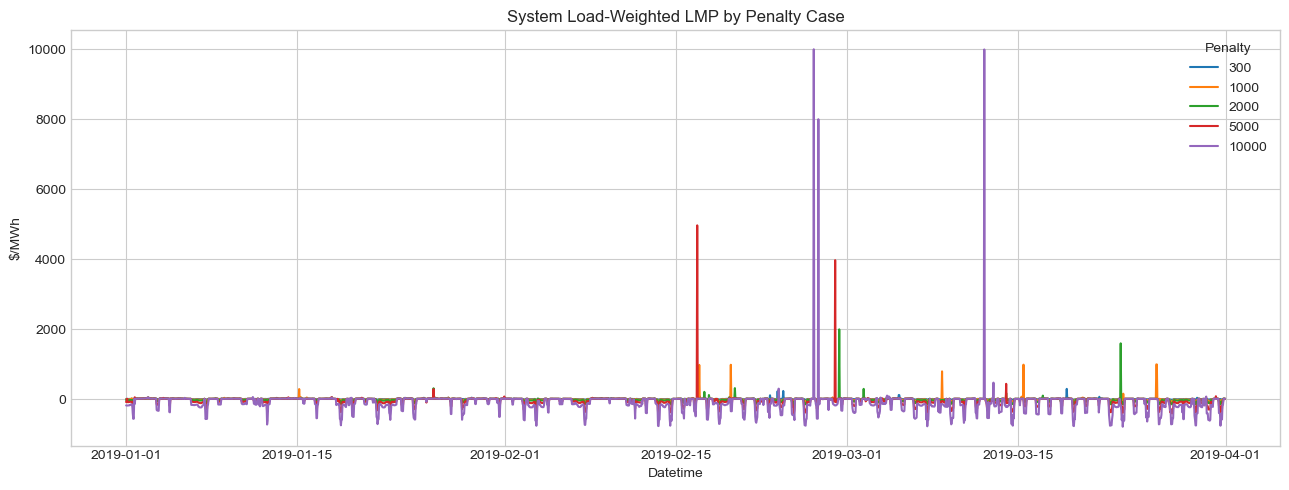

In [76]:
# Build wide hourly export: system LMP + key hourly aggregates by case
wide_parts = []
for m in metrics:
    ts = pd.concat([m["system_lmp_ts"], m["hourly_agg_ts"]], axis=1).reset_index()
    ts["case"] = m["case"]
    ts["penalty"] = m["penalty"]
    wide_parts.append(ts)

wide_df = pd.concat(wide_parts, ignore_index=True)
wide_csv = pcm_dir / "curtailment_penalty_timeseries_wide.csv"
wide_df.to_csv(wide_csv, index=False)
print("Wrote:", wide_csv)
display(wide_df.head())

fig, ax = plt.subplots(figsize=(13, 5))
for m in metrics:
    ax.plot(m["system_lmp_ts"].index, m["system_lmp_ts"].values, label=f"{int(m['penalty'])}")
ax.set_title("System Load-Weighted LMP by Penalty Case")
ax.set_xlabel("Datetime")
ax.set_ylabel("$/MWh")
ax.legend(title="Penalty")
plt.tight_layout()
plt.show()


**Interpretation:**

- **Cap vs dispatch signal:** If curves separate mainly by floor/ceiling clipping levels, penalty is acting as a cap mechanism.
- **Fundamental shift:** If curves shift in central tendency (not just tails), penalty is changing dispatch economics.

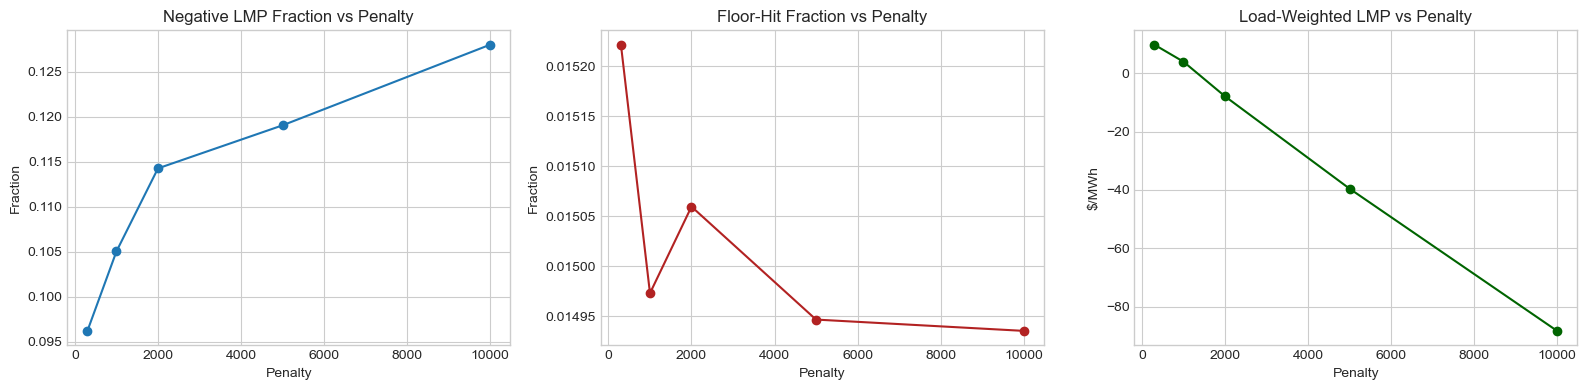

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(summary_df["penalty"], summary_df["neg_lmp_frac"], marker="o")
axes[0].set_title("Negative LMP Fraction vs Penalty")
axes[0].set_xlabel("Penalty")
axes[0].set_ylabel("Fraction")

axes[1].plot(summary_df["penalty"], summary_df["floor_hit_frac"], marker="o", color="firebrick")
axes[1].set_title("Floor-Hit Fraction vs Penalty")
axes[1].set_xlabel("Penalty")
axes[1].set_ylabel("Fraction")

axes[2].plot(summary_df["penalty"], summary_df["weighted_lmp"], marker="o", color="darkgreen")
axes[2].set_title("Load-Weighted LMP vs Penalty")
axes[2].set_xlabel("Penalty")
axes[2].set_ylabel("$/MWh")

plt.tight_layout()
plt.show()


**Interpretation:**

- **Rising `neg_lmp_frac`** with larger penalties usually indicates deeper allowed negative excursions due to wider caps.
- **`floor_hit_frac` trend** quantifies clipping burden directly.
- **`weighted_lmp`** should be interpreted together with clipping metrics to avoid false "improvement" conclusions.

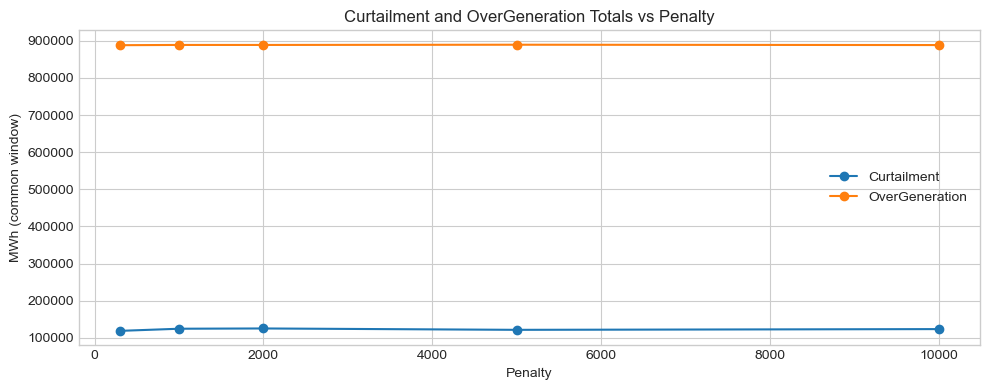

In [78]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(summary_df["penalty"], summary_df["total_curtailment_mwh"], marker="o", label="Curtailment")
ax.plot(summary_df["penalty"], summary_df["total_overgeneration_mwh"], marker="o", label="OverGeneration")
ax.set_title("Curtailment and OverGeneration Totals vs Penalty")
ax.set_xlabel("Penalty")
ax.set_ylabel("MWh (common window)")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:**

- **Joint assessment:** Compare curtailment and overgeneration jointly; curtailment alone can be misleading.
- **Redistribution vs resolution:** If overgeneration remains high while price tails widen, penalty changes are likely redistributing price effects more than solving physical surplus.

## 7. Compact Baseline/Paper Context

This section is intentionally short (per scope): it links curtailment-sweep behavior to prior benchmark evidence.

- Prior report baseline (`model_comparison_prescient_vs_paper_uc_2026-02-28.md`) showed paper UC sampled outputs are **nonnegative**.
- Prescient baseline showed **material negative-price share** and floor hits.
- This sweep should be interpreted as sensitivity around the current Prescient formulation, not as full structural alignment to paper UC.

## 8. Summary Discussion

### What this notebook produced

- Parsed and validated five synced curtailment penalty cases.
- Aligned all cases to a common full-period overlap window.
- Exported:
  - `curtailment_penalty_benchmark_summary.csv`
  - `curtailment_penalty_benchmark_summary.json`
  - `curtailment_penalty_timeseries_wide.csv`

### How to interpret for model tuning

1. Use `neg_lmp_frac` and `floor_hit_frac` together to separate true economic shift from cap clipping.
2. If larger penalties mostly increase tail magnitude (near +/- penalty) without reducing overgeneration, this is not a structural benchmark fix.
3. Treat this sweep as a diagnostic layer; structural alignment work (renewable representation, chronology, pricing workflow) remains primary.

### Caveats

- Case-level penalty metadata is inferred from folder names because manifest file is not present in this synced tree.
- Results reflect the common overlap window, not necessarily the entire intended 90-day horizon for each run.
- Paper references are contextual and sourced from existing project benchmark reports.


---

# Part 2: Deep Analysis of a Selected Penalty Case

The sweep above showed aggregate behavior. Now we select **one penalty case** for detailed bus-level and generator-level analysis, mirroring the full reference notebook methodology. We also load the **no-curtailment baseline** for direct comparison.

**Data sources:** Penalty-case folder (`penalty_{SELECTED_PENALTY}/`) and baseline (`Prescient_2/results/`).

**Variables in scope after this section:** `curt_bus_df`, `base_bus_df`, `curt_thermal_df`, `base_thermal_df`, `curt_renew_df`, `base_renew_df`, `curt_hourly_df`, `base_hourly_df`, `curt_line_df`, `base_line_df`, `gen_meta`, `bus_meta`, `branch_df`.

## 9. Setup: Select Reference Case and Load Baseline

In [79]:
import os

# --- 9.1 Configuration ---
# SELECTED_PENALTY = 1000  # Change this to analyze a different case
SELECTED_PENALTY = 300

# Paths
prescient_dir = (
    repo_root / "gtep" / "data" / "retirement_allowed_no_extreme_half_load" / "Prescient_2"
)
selected_case_dir = exp_root / f"penalty_{SELECTED_PENALTY}"
baseline_results_dir = prescient_dir / "results"  # no-curtailment baseline

# Pre-extracted baseline from 12-month run (if available)
baseline_analysis_dir = Path(
    "/Users/yilu/Documents/development/nd/research/gtep/123_bus_coal"
    "/results/retirement_allowed_no_extreme/12mon_no_hydro_with_curtailment/results_analysis"
)

print(f"Selected penalty case: {SELECTED_PENALTY}")
print(f"  Case dir: {selected_case_dir}")
print(f"  Exists: {selected_case_dir.exists()}")
print(f"\nBaseline (no-curtailment, same scenario):")
print(f"  Dir: {baseline_results_dir}")
print(f"  Exists: {baseline_results_dir.exists()}")
print(f"\n12-month baseline analysis (pre-extracted CSVs):")
print(f"  Dir: {baseline_analysis_dir}")
print(f"  Exists: {baseline_analysis_dir.exists()}")

Selected penalty case: 300
  Case dir: /Users/yilu/Documents/GitHub/idaes-gtep/gtep/data/retirement_allowed_no_extreme_half_load/Prescient_2/experiments/curtailment_penalty/pcm/penalty_300
  Exists: True

Baseline (no-curtailment, same scenario):
  Dir: /Users/yilu/Documents/GitHub/idaes-gtep/gtep/data/retirement_allowed_no_extreme_half_load/Prescient_2/results
  Exists: True

12-month baseline analysis (pre-extracted CSVs):
  Dir: /Users/yilu/Documents/development/nd/research/gtep/123_bus_coal/results/retirement_allowed_no_extreme/12mon_no_hydro_with_curtailment/results_analysis
  Exists: True


In [80]:
# --- 9.2 Helper Functions (from reference notebook) ---

def _prescient_output_to_df(file_name: str) -> pd.DataFrame:
    """Load a Prescient output CSV and build a ``Datetime`` column.

    Parameters
    ----------
    file_name : str
        Path to the Prescient CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame with an added ``Datetime`` column.
    """
    df = pd.read_csv(file_name)
    df["Datetime"] = (
        pd.to_datetime(df["Date"])
        + pd.to_timedelta(df["Hour"], unit="h")
        + pd.to_timedelta(df.get("Minute", 0), unit="m")
    )
    return df


def make_lmp_csv(lmp_path: Path, bus_details_path: str, bus_name: str, output_dir: Path):
    """Extract LMP for one bus and append to wide-format ``Bus_LMP.csv``.

    Parameters
    ----------
    lmp_path : Path
        Output CSV path (created or appended).
    bus_details_path : str
        Path to ``bus_detail.csv``.
    bus_name : str
        Bus name to filter.
    output_dir : Path
        Output directory (unused, kept for API compatibility).
    """
    bus_df_raw = _prescient_output_to_df(bus_details_path)
    bus_data = bus_df_raw[bus_df_raw["Bus"] == bus_name][["Datetime", "LMP DA", "LMP"]].copy()
    bus_data = bus_data.rename(columns={"LMP DA": f"{bus_name}_DA", "LMP": f"{bus_name}_RT"})
    bus_data = bus_data.set_index("Datetime")

    if lmp_path.exists():
        existing = pd.read_csv(lmp_path, index_col="Datetime", parse_dates=True)
        combined = existing.join(bus_data, how="outer")
    else:
        combined = bus_data
    combined.to_csv(lmp_path)


def make_dispatch_csv(dispatch_path: Path, gen_details_path: str, gen_name: str,
                      gen_type: str, other_info: list, output_dir: Path):
    """Extract dispatch for one generator and append to wide-format ``Generator_Dispatch.csv``.

    Parameters
    ----------
    dispatch_path : Path
        Output CSV path (created or appended).
    gen_details_path : str
        Path to the detail CSV (thermal or renewables).
    gen_name : str
        Generator UID to filter.
    gen_type : str
        ``"thermal"`` or ``"renewable"``.
    other_info : list
        Additional columns to extract.
    output_dir : Path
        Output directory (unused, kept for API compatibility).
    """
    if gen_type == "thermal":
        df = _prescient_output_to_df(gen_details_path)
        gen_data = df[df["Generator"] == gen_name][["Datetime", "Dispatch"] + other_info].copy()
        gen_data = gen_data.rename(columns={
            "Dispatch": f"{gen_name}_Dispatch",
            **{c: f"{gen_name}_{c}" for c in other_info}
        })
    else:  # renewable
        df = _prescient_output_to_df(gen_details_path)
        gen_data = df[df["Generator"] == gen_name][["Datetime", "Output"] + other_info].copy()
        gen_data = gen_data.rename(columns={
            "Output": f"{gen_name}_Output",
            **{c: f"{gen_name}_{c}" for c in other_info}
        })
    gen_data = gen_data.set_index("Datetime")

    if dispatch_path.exists():
        existing = pd.read_csv(dispatch_path, index_col="Datetime", parse_dates=True)
        combined = existing.join(gen_data, how="outer")
    else:
        combined = gen_data
    combined.to_csv(dispatch_path)


print("Helper functions defined: _prescient_output_to_df, make_lmp_csv, make_dispatch_csv")

Helper functions defined: _prescient_output_to_df, make_lmp_csv, make_dispatch_csv


In [81]:
# --- 9.3 Load Metadata ---
gen_meta = pd.read_csv(prescient_dir / "gen.csv")
bus_meta = pd.read_csv(prescient_dir / "bus.csv")
branch_df = pd.read_csv(prescient_dir / "branch.csv")

print(f"Generators: {len(gen_meta)}  |  Buses: {len(bus_meta)}  |  Branches: {len(branch_df)}")

# Build lookup dictionaries
bus_name_to_id = dict(zip(bus_meta["Bus Name"], bus_meta["Bus ID"]))
bus_id_to_name = dict(zip(bus_meta["Bus ID"], bus_meta["Bus Name"]))
bus_name_to_zone = dict(zip(bus_meta["Bus Name"], bus_meta["Zone"]))
bus_id_to_zone = dict(zip(bus_meta["Bus ID"], bus_meta["Zone"]))

# Mapping dictionaries
fuel_map = {"G": "Natural Gas", "W": "Wind", "C": "Coal", "S": "Solar", "N": "Nuclear"}
zone_map_full = {
    "COAST": "Coast", "EAST": "East", "FWEST": "Far West", "NORTH": "North",
    "NCENT": "North Central", "SOUTH": "South", "SCENT": "South Central", "WEST": "West",
}

print(f"\nFuel types in fleet: {gen_meta['Fuel'].value_counts().to_dict()}")
print(f"Zones: {bus_meta['Zone'].unique().tolist()}")

Generators: 292  |  Buses: 123  |  Branches: 255

Fuel types in fleet: {'G': 113, 'W': 82, 'S': 72, 'C': 13, 'H': 10, 'N': 2}
Zones: ['EAST', 'NORTH', 'FWEST', 'COAST', 'SOUTH', 'NCENT', 'SCENT', 'WEST']


In [82]:
# --- 9.4 Load Selected Penalty Case & Baseline ---
print(f"Loading penalty_{SELECTED_PENALTY} raw detail files...")

curt_bus_df = _prescient_output_to_df(str(selected_case_dir / "bus_detail.csv"))
curt_thermal_df = _prescient_output_to_df(str(selected_case_dir / "thermal_detail.csv"))
curt_renew_df = _prescient_output_to_df(str(selected_case_dir / "renewables_detail.csv"))
curt_hourly_df = _prescient_output_to_df(str(selected_case_dir / "hourly_summary.csv"))
curt_line_df = _prescient_output_to_df(str(selected_case_dir / "line_detail.csv"))

# Cast Line to int (stored as float)
curt_line_df["Line"] = curt_line_df["Line"].astype(int)
branch_df["UID"] = branch_df["UID"].astype(int)

# LMP column name
lmp_col_name = "LMP DA"

print(f"  bus_detail: {len(curt_bus_df):,} rows")
print(f"  thermal_detail: {len(curt_thermal_df):,} rows")
print(f"  renewables_detail: {len(curt_renew_df):,} rows")
print(f"  hourly_summary: {len(curt_hourly_df):,} rows")
print(f"  line_detail: {len(curt_line_df):,} rows")

# ── Load baseline (no-curtailment) raw data ────────────────────────────────
print(f"\nLoading baseline (no-curtailment) raw detail files...")

base_bus_df = _prescient_output_to_df(str(baseline_results_dir / "bus_detail.csv"))
base_thermal_df = _prescient_output_to_df(str(baseline_results_dir / "thermal_detail.csv"))
base_renew_df = _prescient_output_to_df(str(baseline_results_dir / "renewables_detail.csv"))
base_hourly_df = _prescient_output_to_df(str(baseline_results_dir / "hourly_summary.csv"))
base_line_df = _prescient_output_to_df(str(baseline_results_dir / "line_detail.csv"))
base_line_df["Line"] = base_line_df["Line"].astype(int)

print(f"  bus_detail: {len(base_bus_df):,} rows")
print(f"  thermal_detail: {len(base_thermal_df):,} rows")
print(f"  renewables_detail: {len(base_renew_df):,} rows")
print(f"  hourly_summary: {len(base_hourly_df):,} rows")
print(f"  line_detail: {len(base_line_df):,} rows")

# ── Align to common window ────────────────────────────────────────────────
curt_start, curt_end = curt_bus_df["Datetime"].min(), curt_bus_df["Datetime"].max()
base_start, base_end = base_bus_df["Datetime"].min(), base_bus_df["Datetime"].max()
deep_start = max(curt_start, base_start)
deep_end = min(curt_end, base_end)

print(f"\nCommon window: {deep_start} to {deep_end}")

def deep_window(df):
    return df[(df["Datetime"] >= deep_start) & (df["Datetime"] <= deep_end)].copy()

curt_bus_df = deep_window(curt_bus_df)
curt_thermal_df = deep_window(curt_thermal_df)
curt_renew_df = deep_window(curt_renew_df)
curt_hourly_df = deep_window(curt_hourly_df)
curt_line_df = deep_window(curt_line_df)

base_bus_df = deep_window(base_bus_df)
base_thermal_df = deep_window(base_thermal_df)
base_renew_df = deep_window(base_renew_df)
base_hourly_df = deep_window(base_hourly_df)
base_line_df = deep_window(base_line_df)

print(f"Curtailment bus rows: {len(curt_bus_df):,}  |  Baseline bus rows: {len(base_bus_df):,}")

Loading penalty_300 raw detail files...
  bus_detail: 265,680 rows
  thermal_detail: 276,480 rows
  renewables_detail: 354,240 rows
  hourly_summary: 2,160 rows
  line_detail: 550,800 rows

Loading baseline (no-curtailment) raw detail files...
  bus_detail: 265,680 rows
  thermal_detail: 276,480 rows
  renewables_detail: 332,640 rows
  hourly_summary: 2,160 rows
  line_detail: 550,800 rows

Common window: 2019-01-01 00:00:00 to 2019-03-31 23:00:00
Curtailment bus rows: 265,680  |  Baseline bus rows: 265,680


In [83]:
# --- 9.5 Per-Bus LMP Statistics ---

def compute_bus_lmp_stats(bus_df, lmp_col, penalty=None):
    """Compute per-bus LMP summary statistics.

    Parameters
    ----------
    bus_df : pd.DataFrame
        Bus detail DataFrame with ``Bus`` and LMP columns.
    lmp_col : str
        Name of the LMP column to analyze.
    penalty : float or None
        Curtailment penalty value. If None, uses ``PRESCIENT_PRICE_FLOOR``.

    Returns
    -------
    pd.DataFrame
        Per-bus statistics indexed by bus name.
    """
    stats = bus_df.groupby("Bus")[lmp_col].agg(["mean", "median", "min", "max", "std"])
    stats["pct_negative"] = bus_df.groupby("Bus")[lmp_col].apply(lambda x: (x < 0).mean() * 100)
    if penalty is not None:
        stats["pct_floor"] = bus_df.groupby("Bus")[lmp_col].apply(
            lambda x: (x <= -penalty + 1e-9).mean() * 100
        )
    else:
        stats["pct_floor"] = bus_df.groupby("Bus")[lmp_col].apply(
            lambda x: (x <= -PRESCIENT_PRICE_FLOOR).mean() * 100  # Prescient default floor
        )
    return stats

curt_bus_lmp_stats = compute_bus_lmp_stats(curt_bus_df, lmp_col_name, SELECTED_PENALTY)
base_bus_lmp_stats = compute_bus_lmp_stats(base_bus_df, lmp_col_name, penalty=None)

# System-level load-weighted LMP
curt_sys_lmp = (curt_bus_df["Demand"] * curt_bus_df[lmp_col_name]).sum() / curt_bus_df["Demand"].sum()
base_sys_lmp = (base_bus_df["Demand"] * base_bus_df[lmp_col_name]).sum() / base_bus_df["Demand"].sum()

print("=== System-Level Comparison ===")
print(f"{'Metric':<35} {'Baseline':>12} {'Curtailment':>12}")
print("-" * 60)
print(f"{'Load-weighted LMP ($/MWh)':<35} {base_sys_lmp:>12.2f} {curt_sys_lmp:>12.2f}")
print(f"{'Mean bus LMP ($/MWh)':<35} {base_bus_df[lmp_col_name].mean():>12.2f} {curt_bus_df[lmp_col_name].mean():>12.2f}")
print(f"{'Median bus LMP ($/MWh)':<35} {base_bus_df[lmp_col_name].median():>12.2f} {curt_bus_df[lmp_col_name].median():>12.2f}")
print(f"{'% bus-hours LMP < 0':<35} {(base_bus_df[lmp_col_name] < 0).mean()*100:>11.1f}% {(curt_bus_df[lmp_col_name] < 0).mean()*100:>11.1f}%")
print(f"{'Total curtailment (MWh)':<35} {base_renew_df['Curtailment'].sum():>12,.0f} {curt_renew_df['Curtailment'].sum():>12,.0f}")
print(f"{'Total overgeneration (MWh)':<35} {base_hourly_df['OverGeneration'].sum():>12,.0f} {curt_hourly_df['OverGeneration'].sum():>12,.0f}")

=== System-Level Comparison ===
Metric                                  Baseline  Curtailment
------------------------------------------------------------
Load-weighted LMP ($/MWh)                   3.75         9.79
Mean bus LMP ($/MWh)                      -15.95         2.71
Median bus LMP ($/MWh)                     10.43         9.81
% bus-hours LMP < 0                        10.6%         9.6%
Total curtailment (MWh)                        0      118,560
Total overgeneration (MWh)               889,428      888,328


---

# Part 3: Curtailment Impact Analysis

**Aim:** Investigate how curtailment changes system behavior across all penalty levels, then deep-dive into the selected case.

**Data sources:** `summary_df` (sweep KPIs), `curt_renew_df` (selected-case renewables detail), `gen_meta` (fleet metadata).

**Approach:**
1. Bar-chart sweep of total curtailment and overgeneration by penalty level.
2. Fuel-type and zone breakdown for the selected case.
3. Hour-of-day x month curtailment heatmap.

## 10. Renewable Curtailment Deep Dive

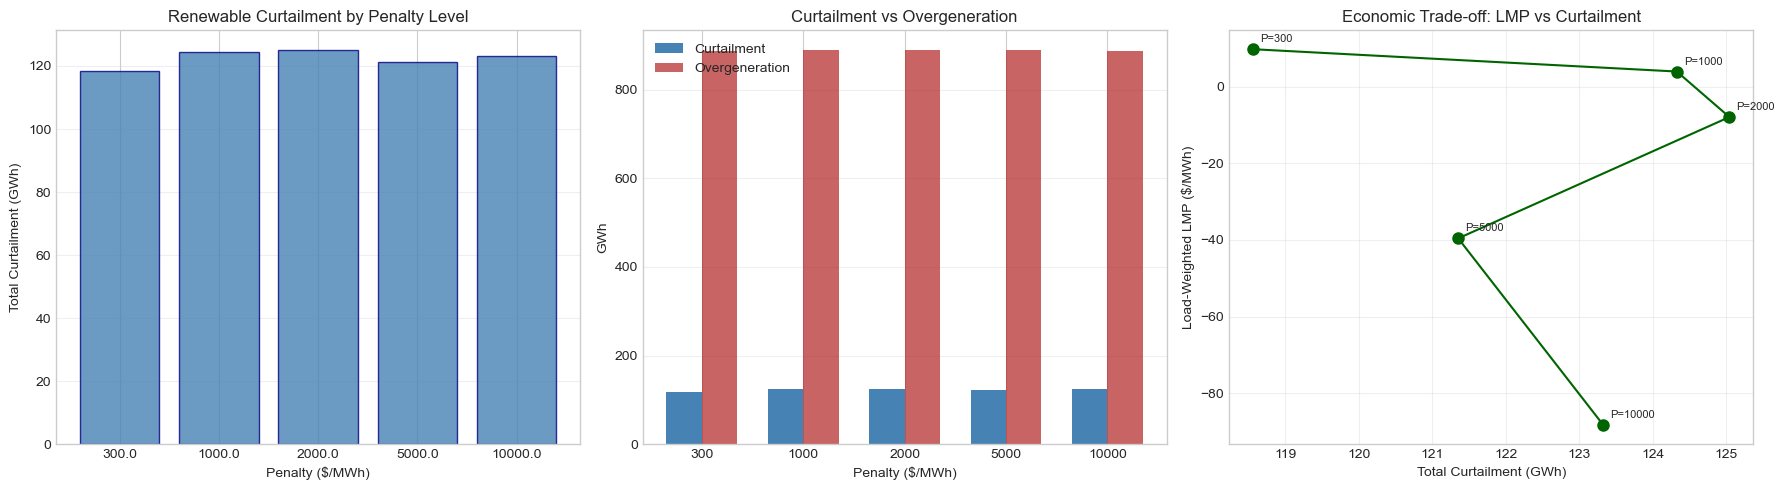

In [84]:
# --- 10.1 Total Curtailment by Penalty Level ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Total curtailment
ax = axes[0]
ax.bar(summary_df["penalty"].astype(str), summary_df["total_curtailment_mwh"] / 1e3,
       color="steelblue", edgecolor="navy", alpha=0.8)
ax.set_xlabel("Penalty ($/MWh)")
ax.set_ylabel("Total Curtailment (GWh)")
ax.set_title("Renewable Curtailment by Penalty Level")
ax.grid(axis="y", alpha=0.3)

# (b) Curtailment vs overgeneration
ax = axes[1]
x = np.arange(len(summary_df))
w = 0.35
ax.bar(x - w/2, summary_df["total_curtailment_mwh"] / 1e3, w, label="Curtailment", color="steelblue")
ax.bar(x + w/2, summary_df["total_overgeneration_mwh"] / 1e3, w, label="Overgeneration", color="firebrick", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(summary_df["penalty"].astype(int).astype(str))
ax.set_xlabel("Penalty ($/MWh)")
ax.set_ylabel("GWh")
ax.set_title("Curtailment vs Overgeneration")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# (c) Cost vs curtailment trade-off
ax = axes[2]
ax.plot(summary_df["total_curtailment_mwh"] / 1e3, summary_df["weighted_lmp"],
        "o-", color="darkgreen", markersize=8)
for _, row in summary_df.iterrows():
    ax.annotate(f"P={int(row['penalty'])}", (row["total_curtailment_mwh"]/1e3, row["weighted_lmp"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel("Total Curtailment (GWh)")
ax.set_ylabel("Load-Weighted LMP ($/MWh)")
ax.set_title("Economic Trade-off: LMP vs Curtailment")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== Curtailment by Fuel Type (GWh) ===
Fuel_Name
Solar    0.0
Wind     0.0

=== Curtailment by Zone (GWh) ===
Zone_Name
South Central    53.280624
North Central    28.047718
West             27.761025
South             9.470828
Coast             0.000000
Far West          0.000000
North             0.000000


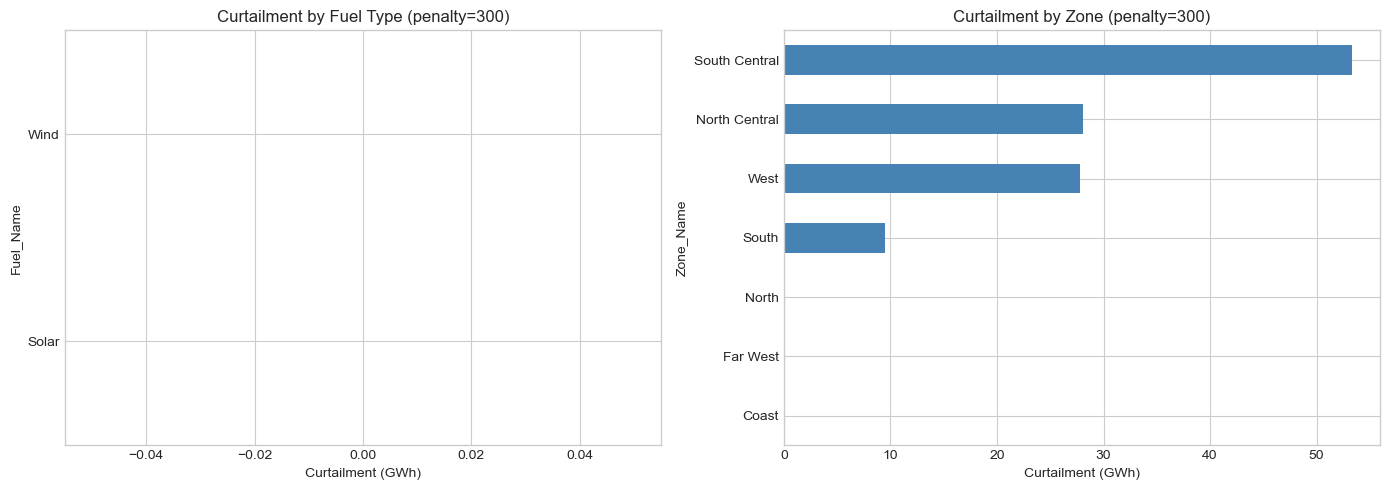

In [85]:
# --- 10.2 Curtailment by Fuel Type and Zone ---

curt_renew_with_meta = curt_renew_df.merge(
    gen_meta[["GEN UID", "Fuel", "Bus ID"]],
    left_on="Generator", right_on="GEN UID", how="left"
)
curt_renew_with_meta["Zone"] = curt_renew_with_meta["Bus ID"].map(bus_id_to_zone)
curt_renew_with_meta["Fuel_Name"] = curt_renew_with_meta["Fuel"].map(fuel_map)
curt_renew_with_meta["Zone_Name"] = curt_renew_with_meta["Zone"].map(zone_map_full)

# By fuel type
curt_by_fuel = curt_renew_with_meta.groupby("Fuel_Name")["Curtailment"].sum() / 1e3
print("=== Curtailment by Fuel Type (GWh) ===")
print(curt_by_fuel.sort_values(ascending=False).to_string())

# By zone
curt_by_zone = curt_renew_with_meta.groupby("Zone_Name")["Curtailment"].sum() / 1e3
print("\n=== Curtailment by Zone (GWh) ===")
print(curt_by_zone.sort_values(ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
curt_by_fuel.sort_values(ascending=True).plot.barh(ax=ax, color=["#ffdd57", "#2ca02c"], edgecolor="none")
ax.set_xlabel("Curtailment (GWh)")
ax.set_title(f"Curtailment by Fuel Type (penalty={SELECTED_PENALTY})")

ax = axes[1]
curt_by_zone.sort_values(ascending=True).plot.barh(ax=ax, color="steelblue", edgecolor="none")
ax.set_xlabel("Curtailment (GWh)")
ax.set_title(f"Curtailment by Zone (penalty={SELECTED_PENALTY})")

plt.tight_layout()
plt.show()

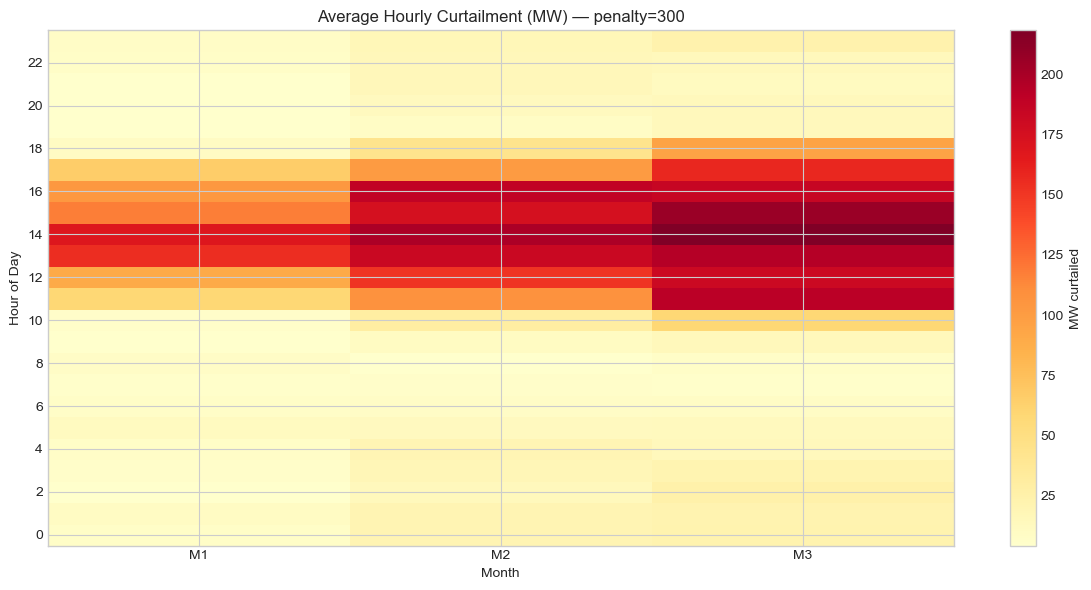

In [86]:
# --- 10.3 Curtailment Heatmap: Hour-of-Day x Month ---

curt_hourly_renew = curt_renew_df.groupby("Datetime")["Curtailment"].sum().reset_index()
curt_hourly_renew["Hour"] = curt_hourly_renew["Datetime"].dt.hour
curt_hourly_renew["Month"] = curt_hourly_renew["Datetime"].dt.month

heatmap_data = curt_hourly_renew.pivot_table(
    values="Curtailment", index="Hour", columns="Month", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd", origin="lower")
ax.set_xticks(range(heatmap_data.shape[1]))
ax.set_xticklabels([f"M{m}" for m in heatmap_data.columns])
ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels(range(0, 24, 2))
ax.set_xlabel("Month")
ax.set_ylabel("Hour of Day")
ax.set_title(f"Average Hourly Curtailment (MW) — penalty={SELECTED_PENALTY}")
plt.colorbar(im, ax=ax, label="MW curtailed")
plt.tight_layout()
plt.show()

## 11. LMP Impact of Curtailment

**Aim:** Quantify the distribution shift in LMPs between the curtailment case and baseline.

**Approach:**
- Histogram overlay of bus-level LMP (clipped to +/-200 for visibility).
- Per-bus negative-LMP frequency scatter (curtailment vs baseline).
- System load-weighted LMP time-series comparison (24h rolling average).
- Zone-level load-weighted LMP delta bar chart.

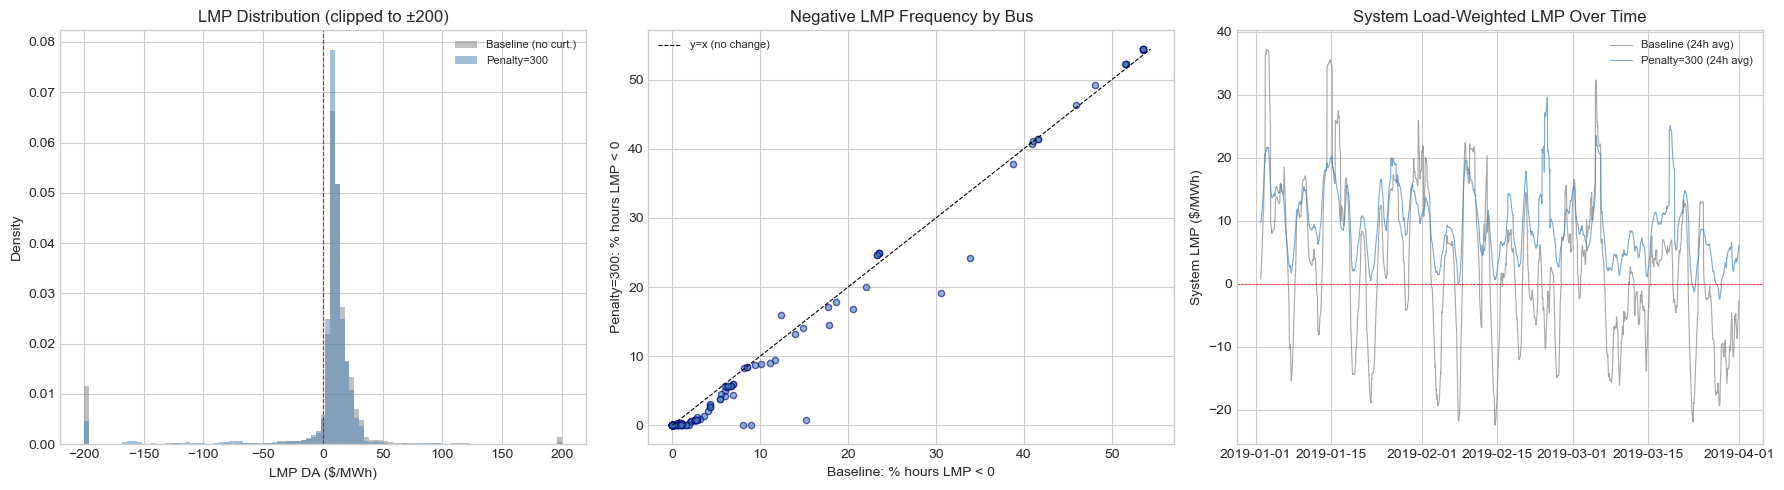

In [87]:
# --- 11.1 LMP Distribution Comparison ---

# NOTE: curt_sys_ts and base_sys_ts are reused in Cells 42 and 51
curt_sys_ts = (
    curt_bus_df.groupby("Datetime")[[lmp_col_name, "Demand"]]
    .apply(lambda x: (x["Demand"] * x[lmp_col_name]).sum() / x["Demand"].sum(), include_groups=False)
    .rename("lmp")
)
base_sys_ts = (
    base_bus_df.groupby("Datetime")[[lmp_col_name, "Demand"]]
    .apply(lambda x: (x["Demand"] * x[lmp_col_name]).sum() / x["Demand"].sum(), include_groups=False)
    .rename("lmp")
)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Histogram overlay (clipped to reasonable range)
ax = axes[0]
clip_range = (-200, 200)
base_lmp_clip = base_bus_df[lmp_col_name].clip(*clip_range)
curt_lmp_clip = curt_bus_df[lmp_col_name].clip(*clip_range)
bins = np.linspace(*clip_range, 100)
ax.hist(base_lmp_clip, bins=bins, alpha=0.5, label="Baseline (no curt.)", color="gray", density=True)
ax.hist(curt_lmp_clip, bins=bins, alpha=0.5, label=f"Penalty={SELECTED_PENALTY}", color="steelblue", density=True)
ax.axvline(0, color="red", linewidth=0.8, linestyle="--")
ax.set_xlabel("LMP DA ($/MWh)")
ax.set_ylabel("Density")
ax.set_title("LMP Distribution (clipped to ±200)")
ax.legend(fontsize=8)

# (b) Negative LMP frequency by bus
ax = axes[1]
ax.scatter(base_bus_lmp_stats["pct_negative"], curt_bus_lmp_stats["pct_negative"],
           s=20, alpha=0.6, color="steelblue", edgecolors="navy")
max_val = max(base_bus_lmp_stats["pct_negative"].max(), curt_bus_lmp_stats["pct_negative"].max())
ax.plot([0, max_val], [0, max_val], "k--", linewidth=0.8, label="y=x (no change)")
ax.set_xlabel("Baseline: % hours LMP < 0")
ax.set_ylabel(f"Penalty={SELECTED_PENALTY}: % hours LMP < 0")
ax.set_title("Negative LMP Frequency by Bus")
ax.legend(fontsize=8)

# (c) Load-weighted system LMP timeseries
ax = axes[2]
ax.plot(base_sys_ts.index, base_sys_ts.rolling(24).mean(), color="gray", alpha=0.7,
        linewidth=0.8, label="Baseline (24h avg)")
ax.plot(curt_sys_ts.index, curt_sys_ts.rolling(24).mean(), color="steelblue", alpha=0.7,
        linewidth=0.8, label=f"Penalty={SELECTED_PENALTY} (24h avg)")
ax.axhline(0, color="red", linewidth=0.5, linestyle="--")
ax.set_ylabel("System LMP ($/MWh)")
ax.set_title("System Load-Weighted LMP Over Time")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

=== Zone-Level LMP Comparison (penalty=300) ===
               Baseline LMP  Curtailment LMP  Delta    Improvement?
Zone_Name                                                          
North Central        $27.61           $21.17 $-6.44  Lower (better)
Coast                $11.21            $9.87 $-1.34  Lower (better)
South                $11.81           $10.70 $-1.11  Lower (better)
South Central        $10.14            $9.97 $-0.17  Lower (better)
East                  $9.53            $9.59  $0.06  Higher (worse)
West                $-39.75           $-5.48 $34.27  Higher (worse)
Far West            $-92.74          $-22.94 $69.80  Higher (worse)
North              $-111.82          $-23.61 $88.21  Higher (worse)


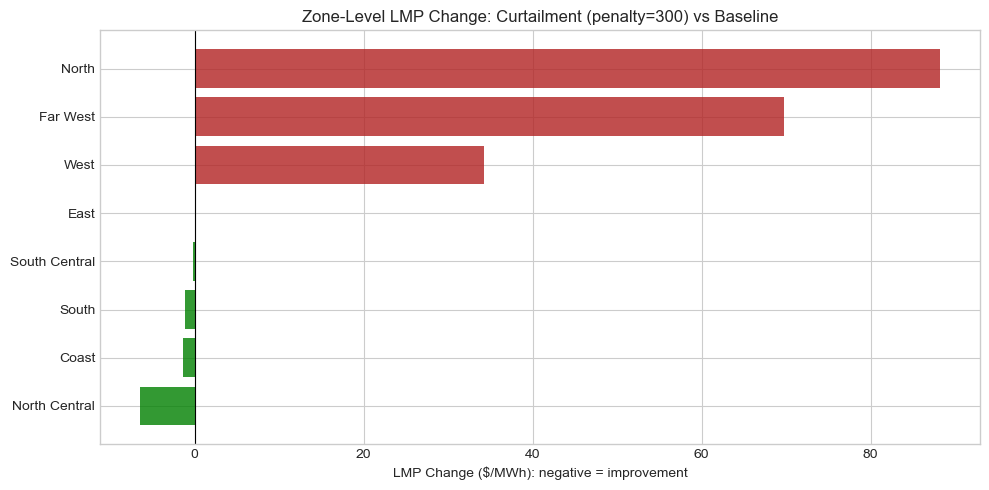

In [88]:
# --- 11.2 Zone-Level LMP Improvement Map ---

# Zone-level load-weighted LMP for both cases
def zone_weighted_lmp(bus_df, lmp_col):
    """Compute load-weighted LMP by zone.

    Parameters
    ----------
    bus_df : pd.DataFrame
        Bus detail with ``Bus``, ``Demand``, and LMP columns.
    lmp_col : str
        Name of the LMP column.

    Returns
    -------
    pd.Series
        Load-weighted LMP indexed by zone name.
    """
    bus_with_zone = bus_df.merge(
        bus_meta[["Bus Name", "Zone"]], left_on="Bus", right_on="Bus Name", how="left"
    )
    zone_name = bus_with_zone["Zone"].map(zone_map_full)
    bus_with_zone["Zone_Name"] = zone_name
    result = bus_with_zone.groupby("Zone_Name").apply(
        lambda g: (g["Demand"] * g[lmp_col]).sum() / g["Demand"].sum()
        if g["Demand"].sum() > 1.0 else np.nan,
        include_groups=False
    )
    return result

curt_zone_lmp = zone_weighted_lmp(curt_bus_df, lmp_col_name)
base_zone_lmp = zone_weighted_lmp(base_bus_df, lmp_col_name)

zone_comparison = pd.DataFrame({
    "Baseline LMP": base_zone_lmp,
    "Curtailment LMP": curt_zone_lmp,
    "Delta": curt_zone_lmp - base_zone_lmp,
    "Improvement?": (curt_zone_lmp > base_zone_lmp).map({True: "Higher (worse)", False: "Lower (better)"}),
}).sort_values("Delta")

print(f"=== Zone-Level LMP Comparison (penalty={SELECTED_PENALTY}) ===")
print(zone_comparison.to_string(float_format=lambda x: f"${x:.2f}"))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["green" if d < 0 else "firebrick" for d in zone_comparison["Delta"]]
ax.barh(zone_comparison.index, zone_comparison["Delta"], color=colors, edgecolor="none", alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("LMP Change ($/MWh): negative = improvement")
ax.set_title(f"Zone-Level LMP Change: Curtailment (penalty={SELECTED_PENALTY}) vs Baseline")
plt.tight_layout()
plt.show()

---

# Part 4: Negative LMP Investigation

**Aim:** Mirror the reference notebook Section 9 with side-by-side curtailment vs baseline comparison.

**Approach (10-step investigation):**
1. Severity and prevalence metrics
2. Spatial patterns (zone-level negative LMP table)
3. Temporal patterns (hour/month heatmaps)
4. Overgeneration correlation
5. Thermal inflexibility (coal/nuclear must-run)
6. Curtailment as safety valve
7. Transmission congestion
8. Worst bus deep dive
9. Worst vs best bus comparison
10. Conclusion

## 12. Negative LMP Analysis

In [89]:
# --- 12.1 Severity and Prevalence ---

def neg_lmp_severity(bus_df, lmp_col, label):
    """Compute negative LMP severity and prevalence metrics.

    Parameters
    ----------
    bus_df : pd.DataFrame
        Bus detail DataFrame.
    lmp_col : str
        LMP column name.
    label : str
        Human-readable case label.

    Returns
    -------
    dict
        Severity metrics including total, negative, and floor-hit bus-hours.
    """
    total = len(bus_df)
    neg = (bus_df[lmp_col] < 0).sum()
    floor = (bus_df[lmp_col] <= -PRESCIENT_PRICE_FLOOR).sum()
    return {
        "label": label,
        "total_bus_hours": total,
        "neg_bus_hours": neg,
        "pct_negative": 100 * neg / total,
        "floor_bus_hours": floor,
        "pct_floor": 100 * floor / total,
    }

sev_base = neg_lmp_severity(base_bus_df, lmp_col_name, "Baseline")
sev_curt = neg_lmp_severity(curt_bus_df, lmp_col_name, f"Penalty={SELECTED_PENALTY}")

print("=== 12.1 Negative LMP Severity ===")
print(f"{'Metric':<30} {'Baseline':>15} {'Curtailment':>15}")
print("-" * 62)
for key in ["total_bus_hours", "neg_bus_hours", "pct_negative", "floor_bus_hours", "pct_floor"]:
    bv = sev_base[key]
    cv = sev_curt[key]
    if "pct" in key:
        print(f"{key:<30} {bv:>14.1f}% {cv:>14.1f}%")
    else:
        print(f"{key:<30} {bv:>15,} {cv:>15,}")

# --- 12.2 Spatial Patterns: Zone-Level Negative LMP ---

def zone_neg_stats(bus_df, lmp_col):
    """Compute zone-level negative LMP statistics.

    Parameters
    ----------
    bus_df : pd.DataFrame
        Bus detail DataFrame with ``Bus`` column.
    lmp_col : str
        LMP column name.

    Returns
    -------
    pd.DataFrame
        Per-zone mean LMP, percent negative, and percent at floor.
    """
    bus_with_zone = bus_df.copy()
    bus_with_zone["Zone"] = bus_with_zone["Bus"].map(bus_name_to_zone)
    bus_with_zone["Zone_Name"] = bus_with_zone["Zone"].map(zone_map_full)
    stats = bus_with_zone.groupby("Zone_Name").agg(
        mean_lmp=(lmp_col, "mean"),
        pct_negative=(lmp_col, lambda x: (x < 0).mean() * 100),
        pct_floor=(lmp_col, lambda x: (x <= -PRESCIENT_PRICE_FLOOR).mean() * 100),
    ).sort_values("mean_lmp")
    return stats

base_zone_neg = zone_neg_stats(base_bus_df, lmp_col_name)
curt_zone_neg = zone_neg_stats(curt_bus_df, lmp_col_name)

print("=== 12.2 Zone-Level Negative LMP Patterns ===")
print(f"\n{'Zone':<16} | {'--- Baseline ---':^30} | {'--- Curtailment ---':^30}")
print(f"{'':16} | {'Mean':>8} {'%Neg':>8} {'%Floor':>8} | {'Mean':>8} {'%Neg':>8} {'%Floor':>8}")
print("-" * 82)
for zone in base_zone_neg.index:
    b = base_zone_neg.loc[zone]
    c = curt_zone_neg.loc[zone] if zone in curt_zone_neg.index else pd.Series({"mean_lmp": np.nan, "pct_negative": np.nan, "pct_floor": np.nan})
    print(f"{zone:<16} | {b['mean_lmp']:>7.1f} {b['pct_negative']:>7.1f}% {b['pct_floor']:>7.1f}% "
          f"| {c['mean_lmp']:>7.1f} {c['pct_negative']:>7.1f}% {c['pct_floor']:>7.1f}%")

=== 12.1 Negative LMP Severity ===
Metric                                Baseline     Curtailment
--------------------------------------------------------------
total_bus_hours                        265,680         265,680
neg_bus_hours                           28,211          25,561
pct_negative                             10.6%            9.6%
floor_bus_hours                          3,999               0
pct_floor                                 1.5%            0.0%
=== 12.2 Zone-Level Negative LMP Patterns ===

Zone             |        --- Baseline ---        |      --- Curtailment ---      
                 |     Mean     %Neg   %Floor |     Mean     %Neg   %Floor
----------------------------------------------------------------------------------
North            |  -234.9    39.9%    17.7% |   -67.7    40.5%     0.0%
Far West         |  -129.6    31.4%     6.2% |   -34.6    32.6%     0.0%
West             |   -46.2    29.2%     0.0% |    -7.7    28.9%     0.0%
South Central    

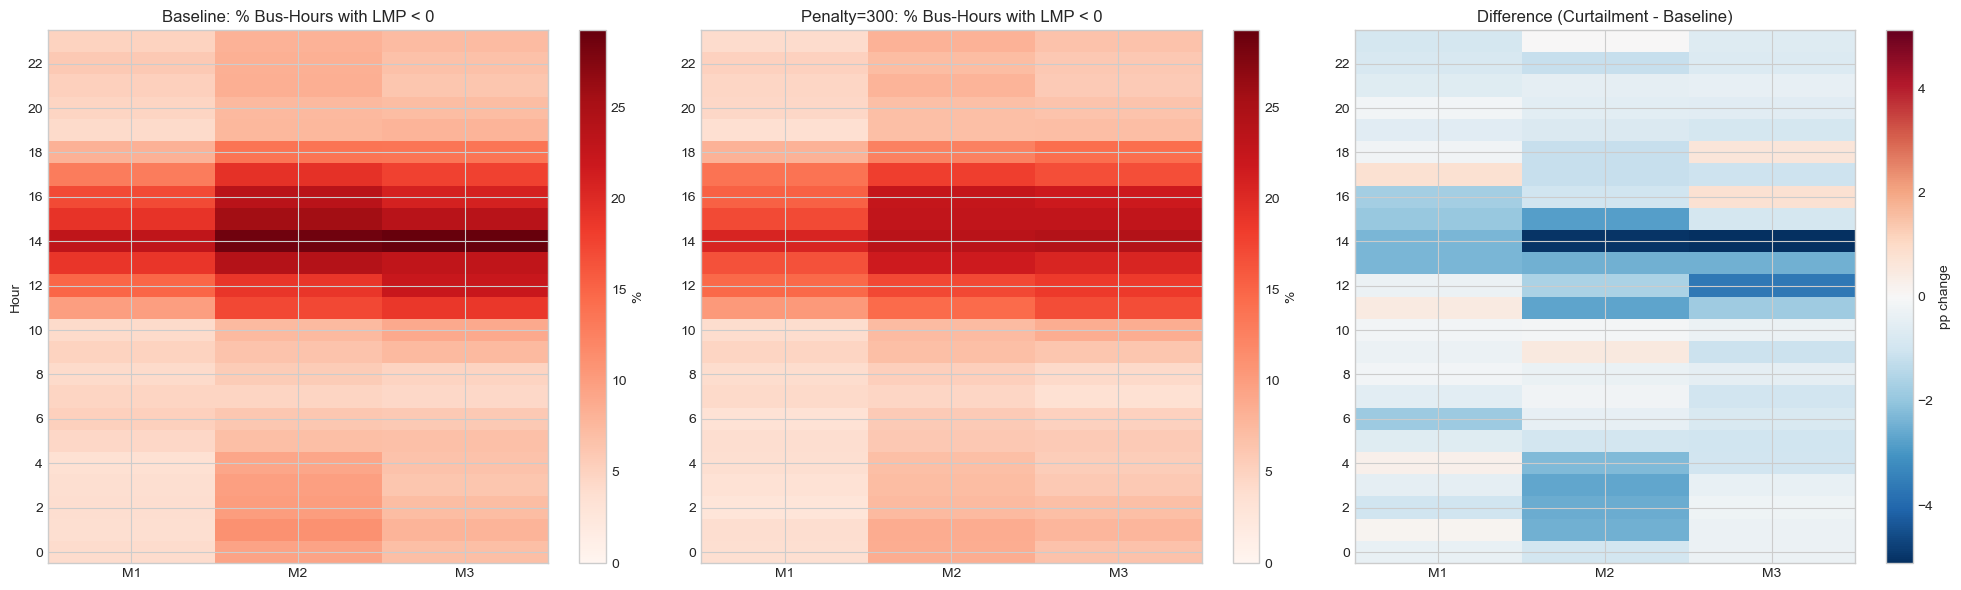

In [90]:
# --- 12.3 Temporal Patterns: Hour/Month Heatmaps ---

def neg_lmp_heatmap_data(bus_df, lmp_col):
    df = bus_df.copy()
    df["Hour"] = df["Datetime"].dt.hour
    df["Month"] = df["Datetime"].dt.month
    df["is_neg"] = (df[lmp_col] < 0).astype(float)
    return df.pivot_table(values="is_neg", index="Hour", columns="Month", aggfunc="mean") * 100

base_heat = neg_lmp_heatmap_data(base_bus_df, lmp_col_name)
curt_heat = neg_lmp_heatmap_data(curt_bus_df, lmp_col_name)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Baseline
ax = axes[0]
vmax = max(base_heat.values.max(), curt_heat.values.max())
im0 = ax.imshow(base_heat.values, aspect="auto", cmap="Reds", origin="lower", vmin=0, vmax=vmax)
ax.set_xticks(range(base_heat.shape[1]))
ax.set_xticklabels([f"M{m}" for m in base_heat.columns])
ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels(range(0, 24, 2))
ax.set_title("Baseline: % Bus-Hours with LMP < 0")
ax.set_ylabel("Hour")
plt.colorbar(im0, ax=ax, label="%")

# Curtailment
ax = axes[1]
im1 = ax.imshow(curt_heat.values, aspect="auto", cmap="Reds", origin="lower", vmin=0, vmax=vmax)
ax.set_xticks(range(curt_heat.shape[1]))
ax.set_xticklabels([f"M{m}" for m in curt_heat.columns])
ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels(range(0, 24, 2))
ax.set_title(f"Penalty={SELECTED_PENALTY}: % Bus-Hours with LMP < 0")
plt.colorbar(im1, ax=ax, label="%")

# Difference
ax = axes[2]
diff_heat = curt_heat - base_heat
dmax = max(abs(diff_heat.values.min()), abs(diff_heat.values.max()))
im2 = ax.imshow(diff_heat.values, aspect="auto", cmap="RdBu_r", origin="lower", vmin=-dmax, vmax=dmax)
ax.set_xticks(range(diff_heat.shape[1]))
ax.set_xticklabels([f"M{m}" for m in diff_heat.columns])
ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels(range(0, 24, 2))
ax.set_title("Difference (Curtailment - Baseline)")
plt.colorbar(im2, ax=ax, label="pp change")

plt.tight_layout()
plt.show()

=== Correlation Matrices ===

Baseline:
                 Mean LMP  Demand  Renewables Used  Overgeneration  Curtailment
Mean LMP          +1.0000 +0.2090          -0.5516         -0.5465          NaN
Demand            +0.2090 +1.0000          -0.1342         -0.1121          NaN
Renewables Used   -0.5516 -0.1342          +1.0000         +0.7640          NaN
Overgeneration    -0.5465 -0.1121          +0.7640         +1.0000          NaN
Curtailment           NaN     NaN              NaN             NaN          NaN

Penalty=300:
                 Mean LMP  Demand  Renewables Used  Overgeneration  Curtailment
Mean LMP          +1.0000 +0.2266          -0.4850         -0.4461      -0.4272
Demand            +0.2266 +1.0000          -0.1351         -0.1128      -0.0426
Renewables Used   -0.4850 -0.1351          +1.0000         +0.7613      +0.6022
Overgeneration    -0.4461 -0.1128          +0.7613         +1.0000      +0.5791
Curtailment       -0.4272 -0.0426          +0.6022         +0.5791

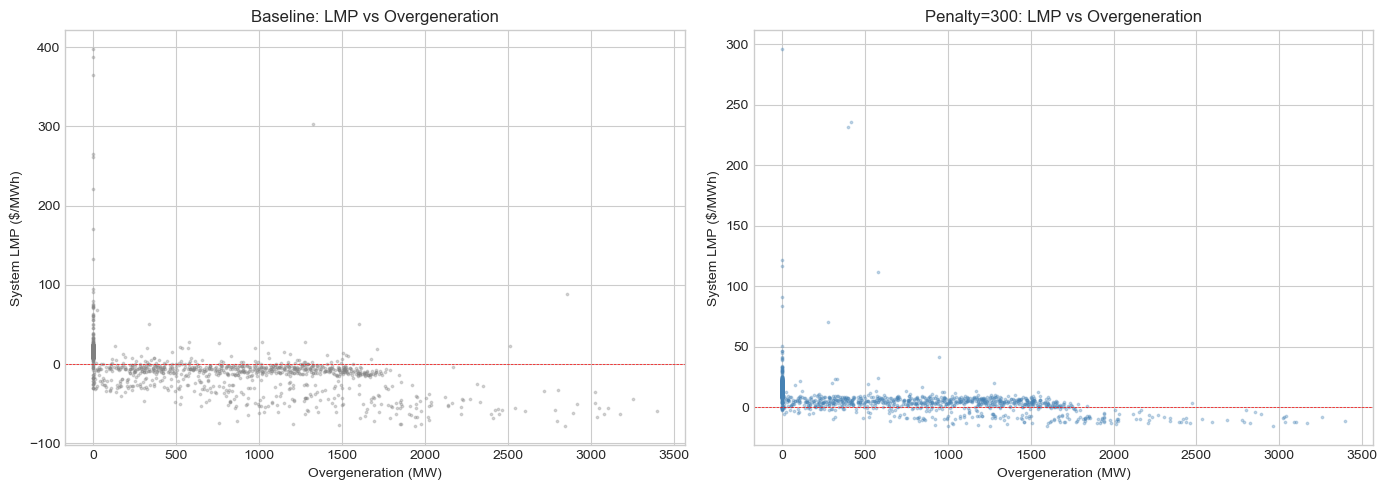

In [91]:
# --- 12.4 Overgeneration Correlation ---

def build_correlation_df(bus_df, hourly_df, renew_df, lmp_col):
    """Build hourly system-level DataFrame for correlation analysis.

    Parameters
    ----------
    bus_df : pd.DataFrame
        Bus detail with ``Datetime``, ``Demand``, and LMP columns.
    hourly_df : pd.DataFrame
        Hourly summary with ``OverGeneration`` and ``RenewablesCurtailment``.
    renew_df : pd.DataFrame
        Renewables detail with ``Output`` column.
    lmp_col : str
        Name of the LMP column.

    Returns
    -------
    pd.DataFrame
        Hourly system-level metrics for correlation analysis.
    """
    sys_lmp = (
        bus_df.groupby("Datetime")[[lmp_col, "Demand"]]
        .apply(lambda x: (x["Demand"] * x[lmp_col]).sum() / x["Demand"].sum(), include_groups=False)
    )
    sys_demand = bus_df.groupby("Datetime")["Demand"].sum()
    sys_renew = renew_df.groupby("Datetime")["Output"].sum()

    hourly_agg = hourly_df.set_index("Datetime")[["OverGeneration", "RenewablesCurtailment"]].copy()
    hourly_agg = hourly_agg[~hourly_agg.index.duplicated(keep="first")]

    merged = pd.DataFrame({
        "Mean LMP": sys_lmp,
        "Demand": sys_demand,
        "Renewables Used": sys_renew,
        "Overgeneration": hourly_agg["OverGeneration"],
        "Curtailment": hourly_agg["RenewablesCurtailment"],
    }).dropna()
    return merged

base_corr_df = build_correlation_df(base_bus_df, base_hourly_df, base_renew_df, lmp_col_name)
curt_corr_df = build_correlation_df(curt_bus_df, curt_hourly_df, curt_renew_df, lmp_col_name)

print("=== Correlation Matrices ===")
print("\nBaseline:")
print(base_corr_df.corr().to_string(float_format=lambda x: f"{x:+.4f}"))
print(f"\nPenalty={SELECTED_PENALTY}:")
print(curt_corr_df.corr().to_string(float_format=lambda x: f"{x:+.4f}"))

# Scatter: LMP vs overgeneration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(base_corr_df["Overgeneration"], base_corr_df["Mean LMP"], s=3, alpha=0.3, color="gray")
ax.set_xlabel("Overgeneration (MW)")
ax.set_ylabel("System LMP ($/MWh)")
ax.set_title("Baseline: LMP vs Overgeneration")
ax.axhline(0, color="red", linewidth=0.5, linestyle="--")

ax = axes[1]
ax.scatter(curt_corr_df["Overgeneration"], curt_corr_df["Mean LMP"], s=3, alpha=0.3, color="steelblue")
ax.set_xlabel("Overgeneration (MW)")
ax.set_ylabel("System LMP ($/MWh)")
ax.set_title(f"Penalty={SELECTED_PENALTY}: LMP vs Overgeneration")
ax.axhline(0, color="red", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

In [92]:
# --- 12.5 Thermal Inflexibility: Coal/Nuclear Min-Load ---

coal_nuc_gens = gen_meta[gen_meta["Fuel"].isin(["C", "N"])].copy()
coal_nuc_gens["Fuel_Name"] = coal_nuc_gens["Fuel"].map(fuel_map)

print("=== Coal + Nuclear Fleet (inflexible generation) ===")
fleet_summary = coal_nuc_gens.groupby("Fuel_Name").agg(
    count=("GEN UID", "count"),
    total_pmax=("PMax MW", "sum"),
    total_pmin=("PMin MW", "sum"),
).reset_index()
fleet_summary["min_load_fraction"] = fleet_summary["total_pmin"] / fleet_summary["total_pmax"]
print(fleet_summary.to_string(index=False))
print(f"\nTotal coal+nuclear PMin: {coal_nuc_gens['PMin MW'].sum():,.0f} MW")
print("This must-run floor creates a minimum generation level that renewables stack on top of.")

=== Coal + Nuclear Fleet (inflexible generation) ===
Fuel_Name  count  total_pmax  total_pmin  min_load_fraction
     Coal     13     14760.7     4428.21                0.3
  Nuclear      2      5138.6     1541.58                0.3

Total coal+nuclear PMin: 5,970 MW
This must-run floor creates a minimum generation level that renewables stack on top of.


=== 12.6 Curtailment as Safety Valve ===
Baseline total curtailment:                0 MWh
Penalty=300 total curtailment:      118,560 MWh


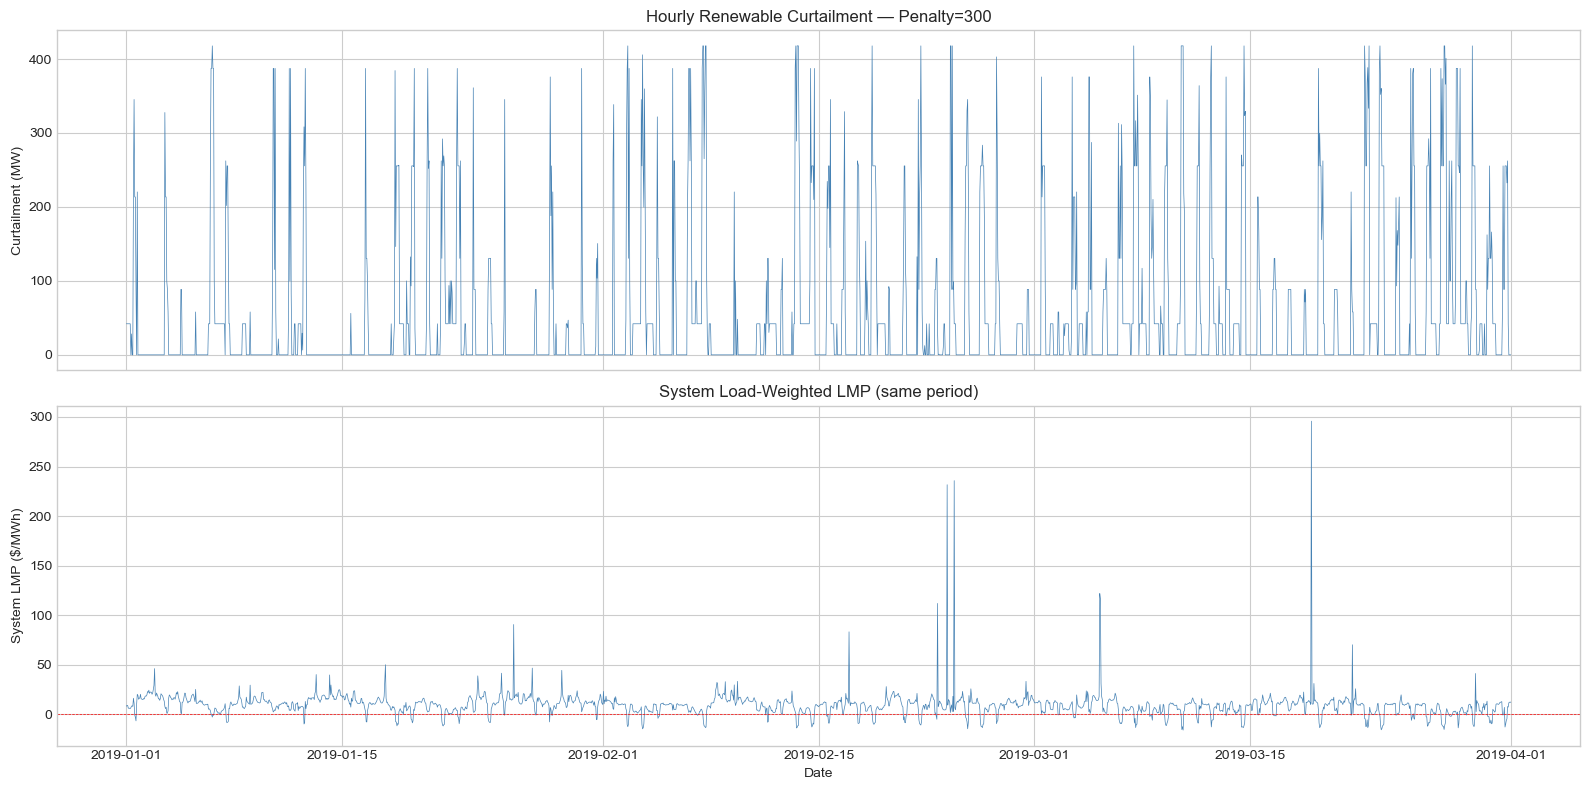


Correlation(Curtailment, System LMP): -0.4272
Negative correlation expected: more curtailment during oversupply → lower LMP


In [93]:
# --- 12.6 Curtailment as Safety Valve ---

# In the baseline, curtailment should be ~0. In curtailment case, it's non-zero.
print("=== 12.6 Curtailment as Safety Valve ===")
print(f"Baseline total curtailment:     {base_renew_df['Curtailment'].sum():>12,.0f} MWh")
print(f"Penalty={SELECTED_PENALTY} total curtailment: {curt_renew_df['Curtailment'].sum():>12,.0f} MWh")

# Hourly curtailment timeseries
curt_hourly_curt = curt_renew_df.groupby("Datetime")["Curtailment"].sum()
base_hourly_curt = base_renew_df.groupby("Datetime")["Curtailment"].sum()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax = axes[0]
ax.plot(curt_hourly_curt.index, curt_hourly_curt.values, linewidth=0.5, color="steelblue")
ax.set_ylabel("Curtailment (MW)")
ax.set_title(f"Hourly Renewable Curtailment — Penalty={SELECTED_PENALTY}")

ax = axes[1]
ax.plot(curt_sys_ts.index, curt_sys_ts.values, linewidth=0.5, color="steelblue", label="System LMP")
ax.axhline(0, color="red", linewidth=0.5, linestyle="--")
ax.set_ylabel("System LMP ($/MWh)")
ax.set_title("System Load-Weighted LMP (same period)")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

# Correlation between curtailment and LMP
curt_vs_lmp = pd.DataFrame({
    "Curtailment": curt_hourly_curt,
    "System_LMP": curt_sys_ts,
}).dropna()
r = curt_vs_lmp.corr().loc["Curtailment", "System_LMP"]
print(f"\nCorrelation(Curtailment, System LMP): {r:+.4f}")
print("Negative correlation expected: more curtailment during oversupply → lower LMP")

=== 12.7 Transmission Congestion ===
Metric                                            Baseline  Curtailment
----------------------------------------------------------------------
Lines at >=95% for >10% of hours                        15           15
Lines at >=95% for >25% of hours                        10           10
Mean congestion freq (%)                              2.2%         2.2%


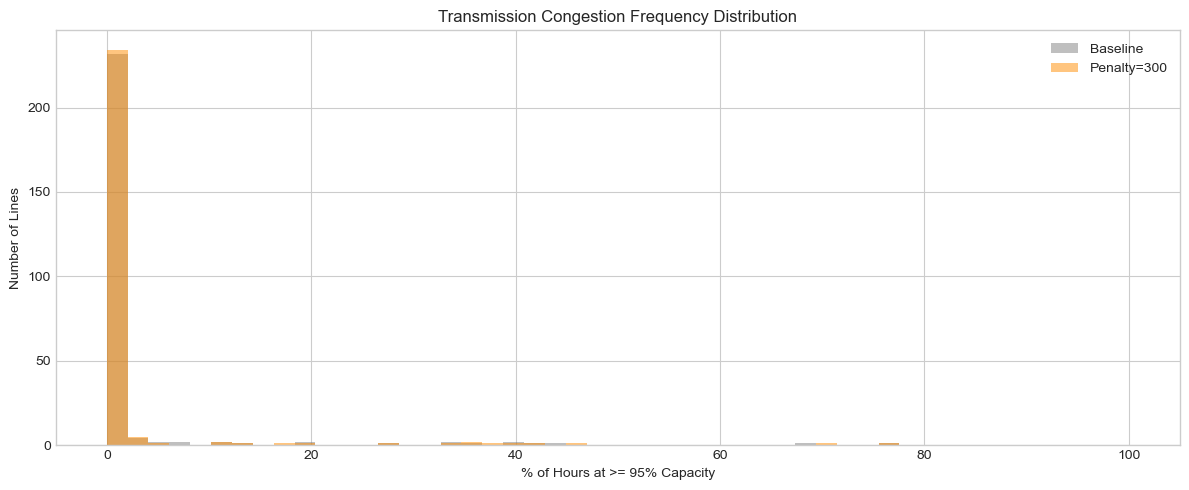

In [94]:
# --- 12.7 Transmission Congestion ---

def compute_congestion(line_df, branch_df_local):
    """Merge line flows with branch ratings and compute utilization.

    Parameters
    ----------
    line_df : pd.DataFrame
        Line detail DataFrame with ``Line`` and ``Flow`` columns.
    branch_df_local : pd.DataFrame
        Branch metadata with ``UID``, ``Cont Rating``.

    Returns
    -------
    pd.DataFrame
        Line flows with ``utilization`` and ``at_capacity`` columns added.
    """
    merged = line_df.merge(
        branch_df_local[["UID", "From Bus", "To Bus", "Cont Rating"]],
        left_on="Line", right_on="UID", how="left"
    )
    merged["utilization"] = merged["Flow"].abs() / merged["Cont Rating"]
    merged["at_capacity"] = merged["utilization"] >= 0.95
    return merged

curt_line_rated = compute_congestion(curt_line_df, branch_df)
base_line_rated = compute_congestion(base_line_df, branch_df)

# Congestion frequency per line
def congestion_frequency(line_rated_df):
    """Compute per-line congestion frequency from rated line data."""
    return line_rated_df.groupby("Line").agg(
        pct_at_capacity=("at_capacity", "mean"),
        mean_util=("utilization", "mean"),
    ).reset_index()

curt_cong = congestion_frequency(curt_line_rated)
curt_cong["pct_at_capacity"] *= 100
base_cong = congestion_frequency(base_line_rated)
base_cong["pct_at_capacity"] *= 100

# Summary
print("=== 12.7 Transmission Congestion ===")
print(f"{'Metric':<45} {'Baseline':>12} {'Curtailment':>12}")
print("-" * 70)
print(f"{'Lines at >=95% for >10% of hours':<45} "
      f"{(base_cong['pct_at_capacity'] > 10).sum():>12} "
      f"{(curt_cong['pct_at_capacity'] > 10).sum():>12}")
print(f"{'Lines at >=95% for >25% of hours':<45} "
      f"{(base_cong['pct_at_capacity'] > 25).sum():>12} "
      f"{(curt_cong['pct_at_capacity'] > 25).sum():>12}")
print(f"{'Mean congestion freq (%)':<45} "
      f"{base_cong['pct_at_capacity'].mean():>11.1f}% "
      f"{curt_cong['pct_at_capacity'].mean():>11.1f}%")

# Histogram comparison
fig, ax = plt.subplots(figsize=(12, 5))
bins = np.linspace(0, 100, 50)
ax.hist(base_cong["pct_at_capacity"], bins=bins, alpha=0.5, label="Baseline", color="gray")
ax.hist(curt_cong["pct_at_capacity"], bins=bins, alpha=0.5, label=f"Penalty={SELECTED_PENALTY}", color="darkorange")
ax.set_xlabel("% of Hours at >= 95% Capacity")
ax.set_ylabel("Number of Lines")
ax.set_title("Transmission Congestion Frequency Distribution")
ax.legend()
plt.tight_layout()
plt.show()

=== Deep Dive: Knox City 345 (Bus 120, Zone: NORTH) ===
Mean DA LMP: $-109.8/MWh
% hours LMP < 0: 54.4%

Connected generators (7):
 GEN UID Unit Type Fuel     PMax MW  PMin MW
     107        CT    G  150.000000     45.0
     116        PV    S  199.333333      0.0
     163      WIND    W  185.399988      0.0
     270      WIND    W  578.999988      0.0
     273        PV    S   47.666667      0.0
     274      WIND    W  746.399988      0.0
     275      WIND    W 1038.999988      0.0

Connected lines (8):
  Line 4.0: Knox City 345 <-> Wheeler 345 (Rating: 1327 MW)
  Line 5.0: Wheeler 345 <-> Knox City 345 (Rating: 1327 MW)
  Line 100.0: Knox City 345 <-> Abilene 2 345 (Rating: 1494 MW)
  Line 113.0: Knox City 345 <-> Rule 2 345 (Rating: 1207 MW)
  Line 197.0: Throckmorton 345 <-> Knox City 345 (Rating: 1327 MW)
  Line 198.0: Throckmorton 345 <-> Knox City 345 (Rating: 1494 MW)
  Line 240.0: Knox City 345 <-> Tell 345 (Rating: 1327 MW)
  Line 252.0: Throckmorton 345 <-> Knox City 345 

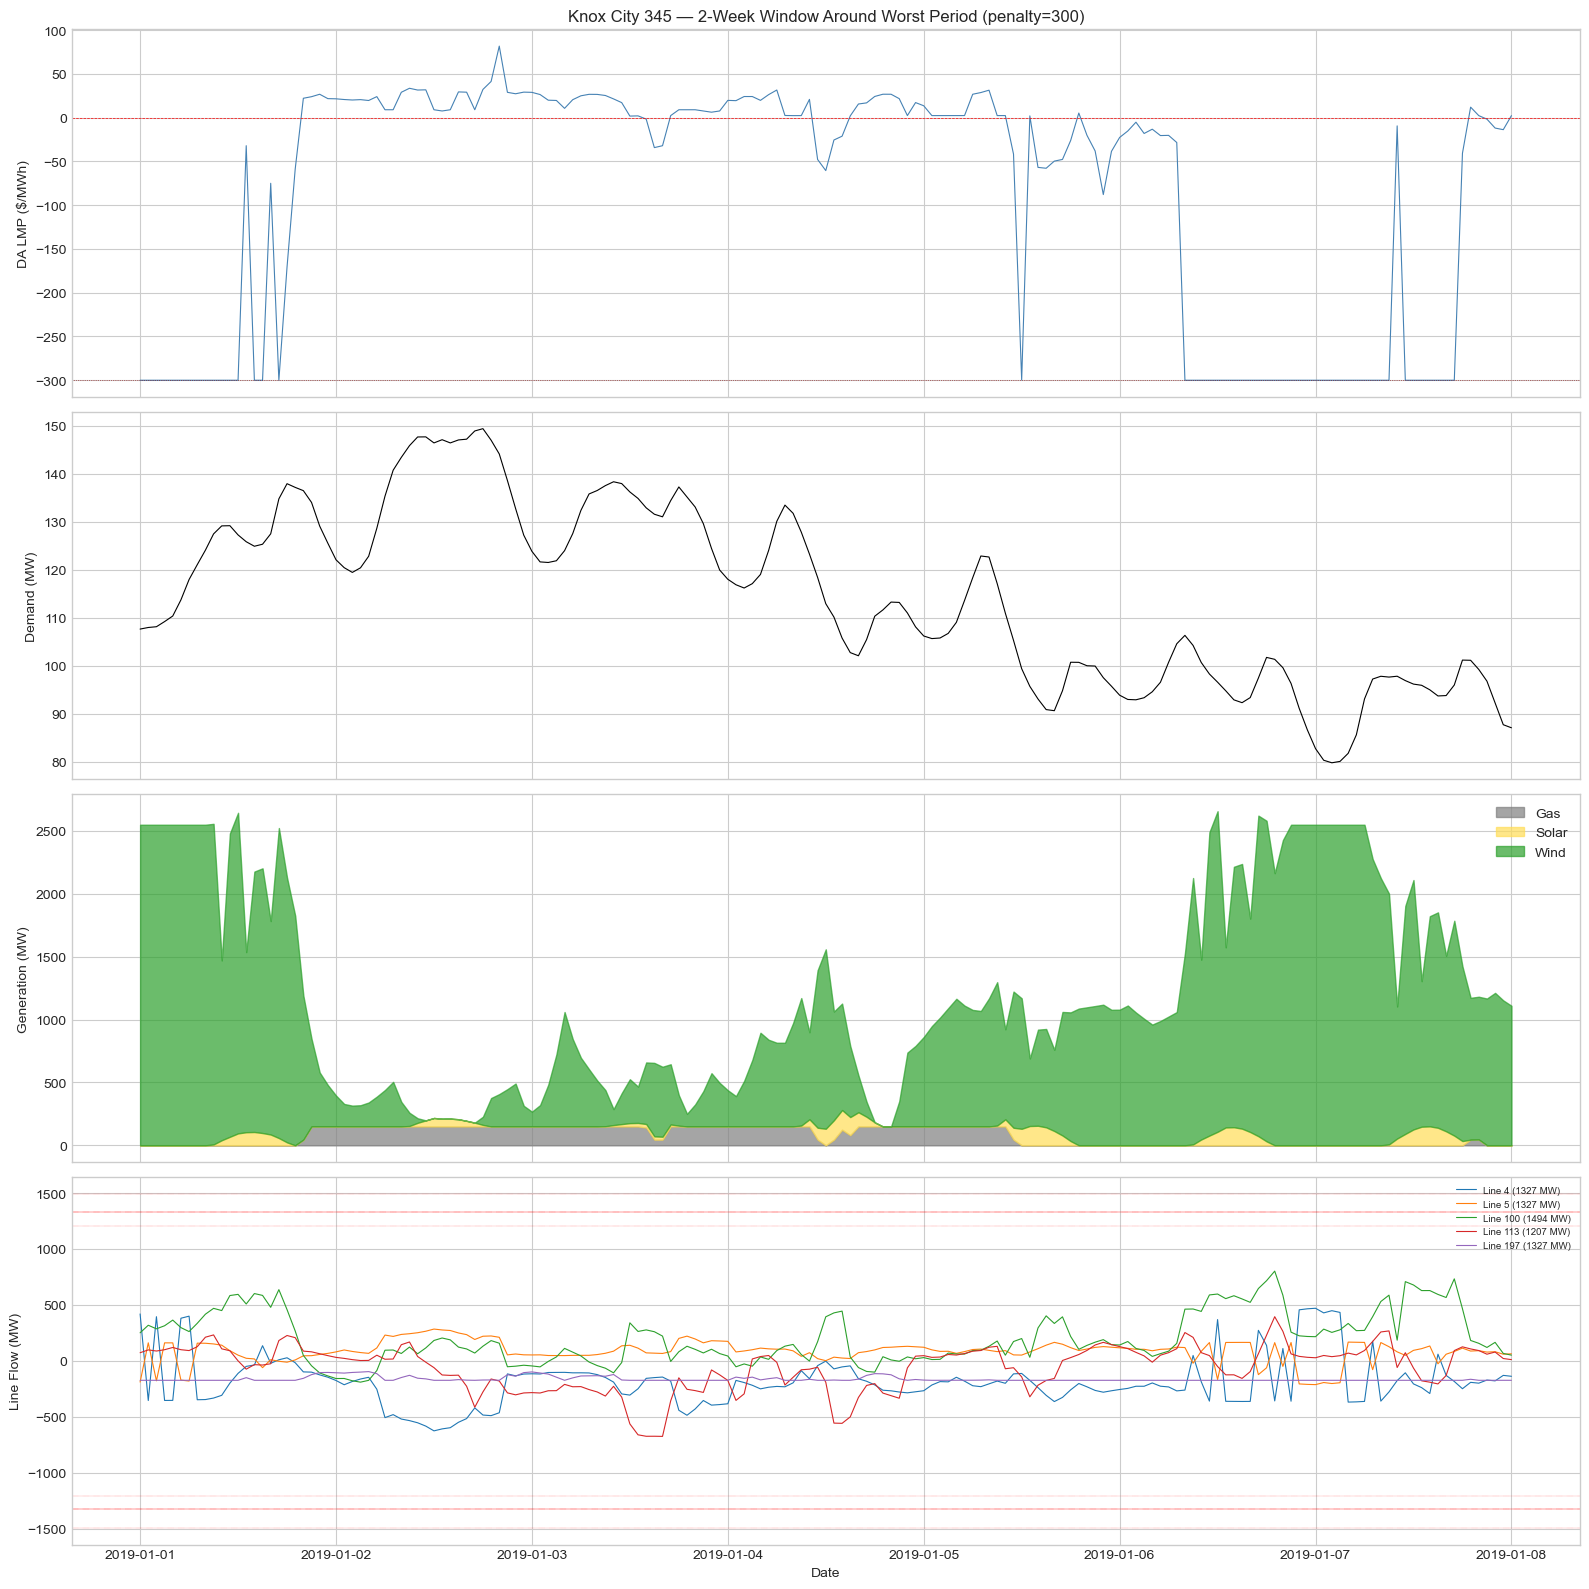

In [95]:
# --- 12.8 Worst Bus Deep Dive (Curtailment Case) ---

worst_bus_name = curt_bus_lmp_stats["mean"].idxmin()
worst_bus_id = bus_name_to_id.get(worst_bus_name)
worst_zone = bus_name_to_zone.get(worst_bus_name, "?")

print(f"=== Deep Dive: {worst_bus_name} (Bus {worst_bus_id}, Zone: {worst_zone}) ===")
print(f"Mean DA LMP: ${curt_bus_lmp_stats.loc[worst_bus_name, 'mean']:.1f}/MWh")
print(f"% hours LMP < 0: {curt_bus_lmp_stats.loc[worst_bus_name, 'pct_negative']:.1f}%")

# Connected generators
local_gens = gen_meta[gen_meta["Bus ID"] == worst_bus_id]
print(f"\nConnected generators ({len(local_gens)}):")
if len(local_gens) > 0:
    print(local_gens[["GEN UID", "Unit Type", "Fuel", "PMax MW", "PMin MW"]].to_string(index=False))

# Connected lines
local_lines = branch_df[(branch_df["From Bus"] == worst_bus_id) | (branch_df["To Bus"] == worst_bus_id)]
print(f"\nConnected lines ({len(local_lines)}):")
for _, row in local_lines.iterrows():
    fn = bus_id_to_name.get(row["From Bus"], "?")
    tn = bus_id_to_name.get(row["To Bus"], "?")
    print(f"  Line {row['UID']}: {fn} <-> {tn} (Rating: {row['Cont Rating']:.0f} MW)")

# 4-panel deep dive plot
bus_data = curt_bus_df[curt_bus_df["Bus"] == worst_bus_name].set_index("Datetime").sort_index()

# Generator dispatch at this bus
local_gen_dispatch = {}
for fuel_code, fuel_name in [("C", "Coal"), ("G", "Gas"), ("N", "Nuclear")]:
    fuel_gens = set(local_gens[local_gens["Fuel"] == fuel_code]["GEN UID"])
    if fuel_gens:
        fuel_disp = curt_thermal_df[curt_thermal_df["Generator"].isin(fuel_gens)]
        if len(fuel_disp) > 0:
            local_gen_dispatch[fuel_name] = fuel_disp.groupby("Datetime")["Dispatch"].sum()

for fuel_code, fuel_name in [("S", "Solar"), ("W", "Wind")]:
    fuel_gens = set(local_gens[local_gens["Fuel"] == fuel_code]["GEN UID"])
    if fuel_gens:
        fuel_disp = curt_renew_df[curt_renew_df["Generator"].isin(fuel_gens)]
        if len(fuel_disp) > 0:
            local_gen_dispatch[fuel_name] = fuel_disp.groupby("Datetime")["Output"].sum()

# 2-week window around worst period
worst_day = bus_data[lmp_col_name].rolling(24, min_periods=1).mean().idxmin()
window_start = max(worst_day - pd.Timedelta(days=7), bus_data.index.min())
window_end = min(worst_day + pd.Timedelta(days=7), bus_data.index.max())

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

# (a) LMP
ax = axes[0]
ax.plot(bus_data.loc[window_start:window_end, lmp_col_name], color="steelblue", linewidth=0.8)
ax.axhline(0, color="red", linewidth=0.5, linestyle="--")
ax.axhline(-SELECTED_PENALTY, color="darkred", linewidth=0.5, linestyle=":")
ax.set_ylabel("DA LMP ($/MWh)")
ax.set_title(f"{worst_bus_name} — 2-Week Window Around Worst Period (penalty={SELECTED_PENALTY})")

# (b) Local demand
ax = axes[1]
ax.plot(bus_data.loc[window_start:window_end, "Demand"], color="black", linewidth=0.8)
ax.set_ylabel("Demand (MW)")

# (c) Connected generation
ax = axes[2]
gen_colors = {"Nuclear": "#ff7f0e", "Coal": "#8c564b", "Gas": "#7f7f7f",
              "Solar": "#ffdd57", "Wind": "#2ca02c"}
bottom = None
for fuel_name, series in local_gen_dispatch.items():
    s = series.loc[window_start:window_end]
    if len(s) == 0:
        continue
    color = gen_colors.get(fuel_name, "gray")
    if bottom is None:
        ax.fill_between(s.index, 0, s, label=fuel_name, color=color, alpha=0.7)
        bottom = s
    else:
        b = bottom.reindex(s.index, fill_value=0)
        ax.fill_between(s.index, b, b + s, label=fuel_name, color=color, alpha=0.7)
        bottom = b + s
ax.set_ylabel("Generation (MW)")
ax.legend(loc="upper right")

# (d) Line flows
ax = axes[3]
local_line_ids = local_lines["UID"].tolist()
for lid in local_line_ids[:5]:
    ld = curt_line_rated[curt_line_rated["Line"] == lid].set_index("Datetime").sort_index()
    ld_win = ld.loc[window_start:window_end]
    if len(ld_win) > 0:
        rating = branch_df[branch_df["UID"] == lid]["Cont Rating"].iloc[0]
        ax.plot(ld_win.index, ld_win["Flow"], linewidth=0.8, label=f"Line {lid} ({rating:.0f} MW)")
        ax.axhline(rating, color="red", linewidth=0.3, linestyle=":")
        ax.axhline(-rating, color="red", linewidth=0.3, linestyle=":")
ax.set_ylabel("Line Flow (MW)")
ax.legend(fontsize=7, loc="upper right")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

=== 12.9 Worst vs Best Bus ===
             Metric Knox City 345 Throckmorton 345
               Zone         NORTH            NCENT
Mean DA LMP ($/MWh)       $-109.8            $51.0
      Median DA LMP        $-20.1            $31.7
    % hours LMP < 0         54.4%             0.0%
   % hours at floor         35.6%             0.0%
         Min DA LMP       $-300.0             $7.7
         Max DA LMP        $287.0           $382.2


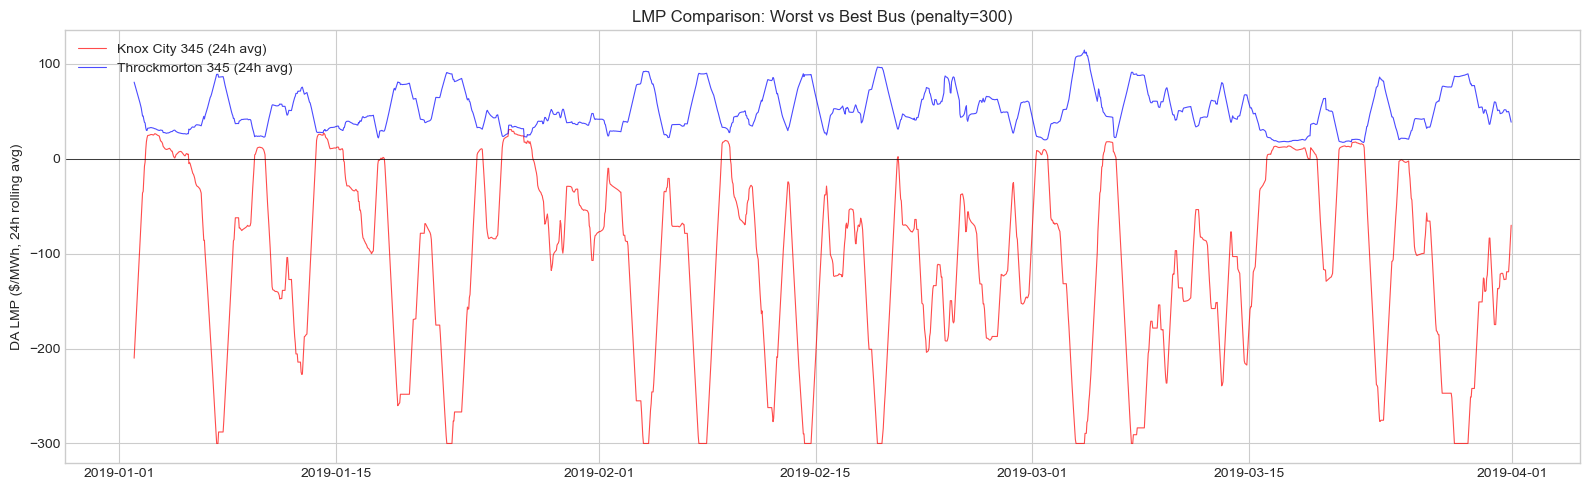

In [96]:
# --- 12.9 Worst vs Best Bus Comparison ---

best_bus_name = curt_bus_lmp_stats["mean"].idxmax()

comparison = pd.DataFrame({
    "Metric": ["Zone", "Mean DA LMP ($/MWh)", "Median DA LMP", "% hours LMP < 0",
               "% hours at floor", "Min DA LMP", "Max DA LMP"],
    worst_bus_name: [
        bus_name_to_zone.get(worst_bus_name, "?"),
        f"${curt_bus_lmp_stats.loc[worst_bus_name, 'mean']:.1f}",
        f"${curt_bus_lmp_stats.loc[worst_bus_name, 'median']:.1f}",
        f"{curt_bus_lmp_stats.loc[worst_bus_name, 'pct_negative']:.1f}%",
        f"{curt_bus_lmp_stats.loc[worst_bus_name, 'pct_floor']:.1f}%",
        f"${curt_bus_lmp_stats.loc[worst_bus_name, 'min']:.1f}",
        f"${curt_bus_lmp_stats.loc[worst_bus_name, 'max']:.1f}",
    ],
    best_bus_name: [
        bus_name_to_zone.get(best_bus_name, "?"),
        f"${curt_bus_lmp_stats.loc[best_bus_name, 'mean']:.1f}",
        f"${curt_bus_lmp_stats.loc[best_bus_name, 'median']:.1f}",
        f"{curt_bus_lmp_stats.loc[best_bus_name, 'pct_negative']:.1f}%",
        f"{curt_bus_lmp_stats.loc[best_bus_name, 'pct_floor']:.1f}%",
        f"${curt_bus_lmp_stats.loc[best_bus_name, 'min']:.1f}",
        f"${curt_bus_lmp_stats.loc[best_bus_name, 'max']:.1f}",
    ],
})
print("=== 12.9 Worst vs Best Bus ===")
print(comparison.to_string(index=False))

# Overlaid LMP timeseries
worst_ts = curt_bus_df[curt_bus_df["Bus"] == worst_bus_name].set_index("Datetime")[lmp_col_name].sort_index()
best_ts = curt_bus_df[curt_bus_df["Bus"] == best_bus_name].set_index("Datetime")[lmp_col_name].sort_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(worst_ts.index, worst_ts.rolling(24).mean(),
        color="red", alpha=0.7, linewidth=0.8, label=f"{worst_bus_name} (24h avg)")
ax.plot(best_ts.index, best_ts.rolling(24).mean(),
        color="blue", alpha=0.7, linewidth=0.8, label=f"{best_bus_name} (24h avg)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_ylabel("DA LMP ($/MWh, 24h rolling avg)")
ax.set_title(f"LMP Comparison: Worst vs Best Bus (penalty={SELECTED_PENALTY})")
ax.legend()
plt.tight_layout()
plt.show()

### 12.10 Negative LMP Conclusion

The curtailment penalty changes the *magnitude* of negative LMP excursions (bounded by the penalty value) but does NOT fundamentally eliminate them. The root causes remain:
1. **Thermal inflexibility** (coal+nuclear must-run)
2. **Transmission congestion** (West Texas corridors)
3. **Renewable oversupply** (2035 scenario with high wind/solar penetration)

Curtailment acts as a safety valve — it prevents the most extreme negative prices but does not resolve the structural oversupply.

---

# Part 5: Benchmarking Against Lu et al. 2025

**Aim:** Replicate key figures and tables from the paper using curtailment-case data, with paper benchmark overlays.

**Data sources:** `gen_meta` + `bus_meta` (fleet), `curt_bus_df` / `curt_renew_df` / `curt_line_df` (selected case), `curt_sys_ts` (system LMP), `daily_demand` (day classification).

**Approach:** Reproduce Paper Tables I-II and Figures 3, 4, 6, 7, 10a-d, 11, 12, 13, 14 with side-by-side comparison bands.

## 13. Paper Benchmark Comparison

In [97]:
# --- 13.1 Generator Fleet Comparison (Paper Tables I & II) ---

# Paper Table I: Total Number of Different Fuel Type Generators
paper_table_I = {
    "Coast":         {"Natural Gas": 31, "Wind": 0,  "Coal": 2,  "Solar": 8,  "Nuclear": 1, "Hydro": 0},
    "East":          {"Natural Gas": 15, "Wind": 0,  "Coal": 2,  "Solar": 0,  "Nuclear": 0, "Hydro": 0},
    "Far West":      {"Natural Gas": 4,  "Wind": 11, "Coal": 0,  "Solar": 17, "Nuclear": 0, "Hydro": 0},
    "North":         {"Natural Gas": 4,  "Wind": 9,  "Coal": 1,  "Solar": 6,  "Nuclear": 0, "Hydro": 1},
    "North Central": {"Natural Gas": 14, "Wind": 10, "Coal": 4,  "Solar": 9,  "Nuclear": 1, "Hydro": 1},
    "South":         {"Natural Gas": 11, "Wind": 18, "Coal": 1,  "Solar": 3,  "Nuclear": 0, "Hydro": 1},
    "South Central": {"Natural Gas": 29, "Wind": 0,  "Coal": 3,  "Solar": 23, "Nuclear": 0, "Hydro": 6},
    "West":          {"Natural Gas": 5,  "Wind": 34, "Coal": 0,  "Solar": 6,  "Nuclear": 0, "Hydro": 1},
}

# Paper Table II: Total Capacities (MW)
paper_table_II = {
    "Coast":         {"Natural Gas": 11925, "Wind": 0,     "Coal": 2373, "Solar": 37,   "Nuclear": 2709, "Hydro": 0},
    "East":          {"Natural Gas": 6385,  "Wind": 0,     "Coal": 3089, "Solar": 0,    "Nuclear": 0,    "Hydro": 0},
    "Far West":      {"Natural Gas": 3892,  "Wind": 2341,  "Coal": 0,    "Solar": 1760, "Nuclear": 0,    "Hydro": 0},
    "North":         {"Natural Gas": 2236,  "Wind": 3990,  "Coal": 802,  "Solar": 256,  "Nuclear": 0,    "Hydro": 80},
    "North Central": {"Natural Gas": 12093, "Wind": 1277,  "Coal": 4529, "Solar": 42,   "Nuclear": 2431, "Hydro": 42},
    "South":         {"Natural Gas": 7480,  "Wind": 6717,  "Coal": 410,  "Solar": 97,   "Nuclear": 0,    "Hydro": 31},
    "South Central": {"Natural Gas": 11075, "Wind": 0,     "Coal": 3560, "Solar": 159,  "Nuclear": 0,    "Hydro": 287},
    "West":          {"Natural Gas": 920,   "Wind": 10157, "Coal": 0,    "Solar": 131,  "Nuclear": 0,    "Hydro": 58},
}

# Build our fleet tables
gen_with_zone = gen_meta.merge(bus_meta[["Bus ID", "Zone"]], on="Bus ID", how="left")
gen_with_zone["Fuel_Name"] = gen_with_zone["Fuel"].map(fuel_map)
gen_with_zone["Zone_Name"] = gen_with_zone["Zone"].map(zone_map_full)

fuel_order = ["Natural Gas", "Wind", "Coal", "Solar", "Nuclear"]
zone_order = ["Coast", "East", "Far West", "North", "North Central", "South", "South Central", "West"]

our_table_I = gen_with_zone.groupby(["Zone_Name", "Fuel_Name"]).size().unstack(fill_value=0)
our_table_I = our_table_I.reindex(index=zone_order, columns=fuel_order, fill_value=0)

our_table_II = gen_with_zone.groupby(["Zone_Name", "Fuel_Name"])["PMax MW"].sum().unstack(fill_value=0)
our_table_II = our_table_II.reindex(index=zone_order, columns=fuel_order, fill_value=0)

paper_I_df = pd.DataFrame(paper_table_I).T.reindex(index=zone_order, columns=fuel_order + ["Hydro"], fill_value=0)
paper_II_df = pd.DataFrame(paper_table_II).T.reindex(index=zone_order, columns=fuel_order + ["Hydro"], fill_value=0)

print("=" * 80)
print("TABLE I COMPARISON: Generator Counts by Zone and Fuel Type")
print("=" * 80)
print(f"\n{'Zone':<16} | {'Paper (2019)':^42} | {'Ours (2035)':^36}")
print(f"{'':16} | {'Gas':>5} {'Wind':>5} {'Coal':>5} {'Solar':>6} {'Nuc':>4} {'Hydro':>6} | {'Gas':>5} {'Wind':>5} {'Coal':>5} {'Solar':>6} {'Nuc':>4}")
print("-" * 80)
for zone in zone_order:
    p = paper_I_df.loc[zone]
    o = our_table_I.loc[zone]
    print(f"{zone:<16} | {p['Natural Gas']:5.0f} {p['Wind']:5.0f} {p['Coal']:5.0f} {p['Solar']:6.0f} {p['Nuclear']:4.0f} {p['Hydro']:6.0f} | {o['Natural Gas']:5.0f} {o['Wind']:5.0f} {o['Coal']:5.0f} {o['Solar']:6.0f} {o['Nuclear']:4.0f}")
paper_tot = paper_I_df.sum()
our_tot = our_table_I.sum()
print("-" * 80)
print(f"{'Total':<16} | {paper_tot['Natural Gas']:5.0f} {paper_tot['Wind']:5.0f} {paper_tot['Coal']:5.0f} {paper_tot['Solar']:6.0f} {paper_tot['Nuclear']:4.0f} {paper_tot['Hydro']:6.0f} | {our_tot['Natural Gas']:5.0f} {our_tot['Wind']:5.0f} {our_tot['Coal']:5.0f} {our_tot['Solar']:6.0f} {our_tot['Nuclear']:4.0f}")

TABLE I COMPARISON: Generator Counts by Zone and Fuel Type

Zone             |                Paper (2019)                |             Ours (2035)             
                 |   Gas  Wind  Coal  Solar  Nuc  Hydro |   Gas  Wind  Coal  Solar  Nuc
--------------------------------------------------------------------------------
Coast            |    31     0     2      8    1      0 |    31     0     2      8    1
East             |    15     0     2      0    0      0 |    15     0     2      0    0
Far West         |     4    11     0     17    0      0 |     4    11     0     17    0
North            |     4     9     1      6    0      1 |     4     9     1      6    0
North Central    |    14    10     4      9    1      1 |    14    10     4      9    1
South            |    11    18     1      3    0      1 |    11    18     1      3    0
South Central    |    29     0     3     23    0      6 |    29     0     3     23    0
West             |     5    34     0      6    0      

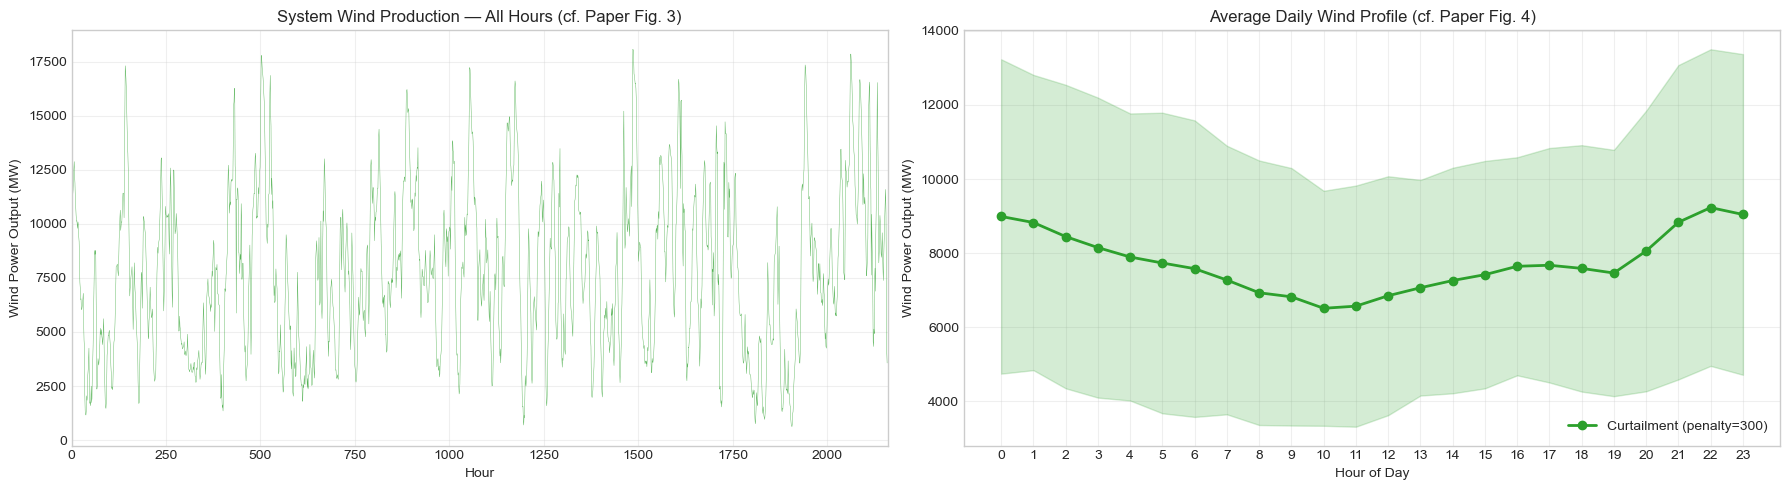

Total wind generation: 16.73 TWh
Wind capacity factor: 31.6%


In [98]:
# --- 13.2-13.3 Wind Production & Daily Profile (Paper Figs 3-4) ---

wind_gen_ids = set(gen_meta[gen_meta["Fuel"] == "W"]["GEN UID"])
curt_wind_df = curt_renew_df[curt_renew_df["Generator"].isin(wind_gen_ids)].copy()
wind_hourly = curt_wind_df.groupby("Datetime")["Output"].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Fig 3: Wind timeseries
ax = axes[0]
ax.plot(range(len(wind_hourly)), wind_hourly.values, linewidth=0.3, color="#2ca02c", alpha=0.8)
ax.set_xlabel("Hour")
ax.set_ylabel("Wind Power Output (MW)")
ax.set_title("System Wind Production — All Hours (cf. Paper Fig. 3)")
ax.set_xlim(0, len(wind_hourly))
ax.grid(True, alpha=0.3)

# Fig 4: Average daily wind profile
wind_hourly_profile = wind_hourly.reset_index()
wind_hourly_profile.columns = ["Datetime", "WindOutput"]
wind_hourly_profile["Hour"] = wind_hourly_profile["Datetime"].dt.hour
avg_wind = wind_hourly_profile.groupby("Hour")["WindOutput"].agg(["mean", "std"])

ax = axes[1]
ax.plot(avg_wind.index, avg_wind["mean"], "o-", color="#2ca02c", linewidth=2, markersize=6,
        label=f"Curtailment (penalty={SELECTED_PENALTY})")
ax.fill_between(avg_wind.index, avg_wind["mean"] - avg_wind["std"],
                avg_wind["mean"] + avg_wind["std"], alpha=0.2, color="#2ca02c")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Wind Power Output (MW)")
ax.set_title("Average Daily Wind Profile (cf. Paper Fig. 4)")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

wind_cap = gen_meta[gen_meta["Fuel"] == "W"]["PMax MW"].sum()
print(f"Total wind generation: {wind_hourly.sum()/1e6:.2f} TWh")
print(f"Wind capacity factor: {wind_hourly.mean()/wind_cap*100:.1f}%")

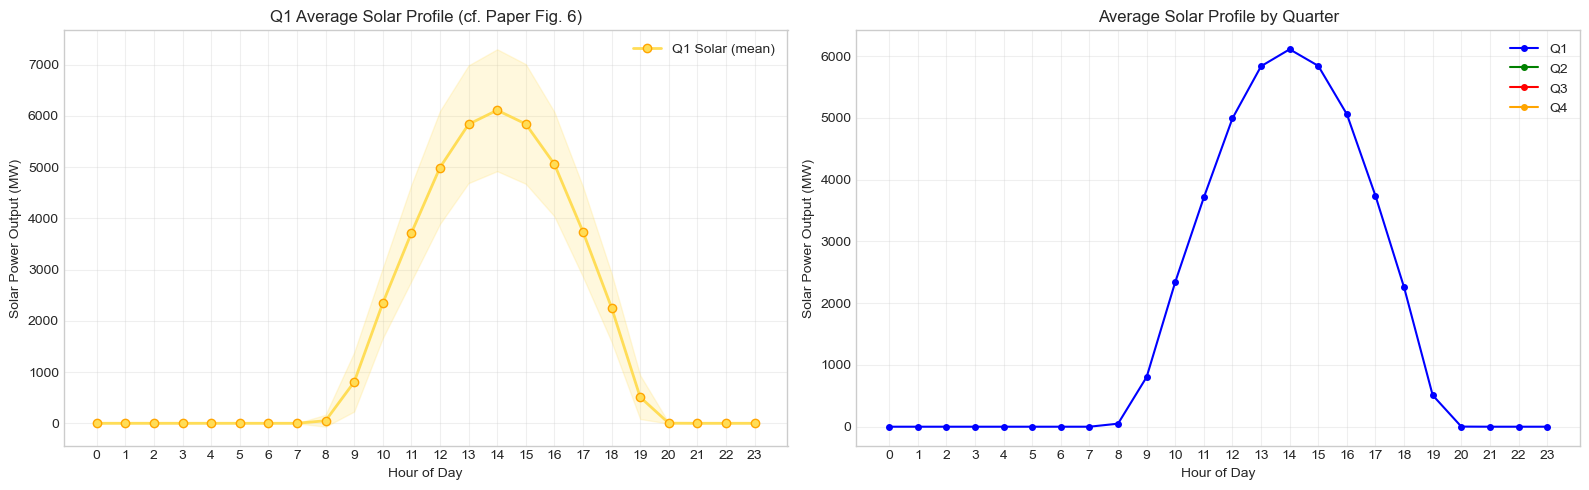

Total solar generation: 3.71 TWh
Solar capacity factor: 20.8%


In [99]:
# --- 13.4-13.5 Solar Profiles (Paper Figs 6-7) ---

solar_gen_ids = set(gen_meta[gen_meta["Fuel"] == "S"]["GEN UID"])
curt_solar_df = curt_renew_df[curt_renew_df["Generator"].isin(solar_gen_ids)].copy()
solar_hourly = curt_solar_df.groupby("Datetime")["Output"].sum().sort_index()

solar_profile = solar_hourly.reset_index()
solar_profile.columns = ["Datetime", "SolarOutput"]
solar_profile["Hour"] = solar_profile["Datetime"].dt.hour
solar_profile["Quarter"] = solar_profile["Datetime"].dt.quarter

# Q1 average solar profile (Paper Fig 6)
q1_solar = solar_profile[solar_profile["Quarter"] == 1].groupby("Hour")["SolarOutput"].agg(["mean", "std"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(q1_solar.index, q1_solar["mean"], "o-", color="#ffdd57", markeredgecolor="orange",
        linewidth=2, markersize=6, label="Q1 Solar (mean)")
ax.fill_between(q1_solar.index, q1_solar["mean"] - q1_solar["std"],
                q1_solar["mean"] + q1_solar["std"], alpha=0.2, color="#ffdd57")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Solar Power Output (MW)")
ax.set_title("Q1 Average Solar Profile (cf. Paper Fig. 6)")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

# All-quarter comparison
ax = axes[1]
q_colors = {1: "blue", 2: "green", 3: "red", 4: "orange"}
for q in [1, 2, 3, 4]:
    q_data = solar_profile[solar_profile["Quarter"] == q].groupby("Hour")["SolarOutput"].mean()
    ax.plot(q_data.index, q_data.values, "o-", color=q_colors[q], linewidth=1.5, markersize=4, label=f"Q{q}")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Solar Power Output (MW)")
ax.set_title("Average Solar Profile by Quarter")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

solar_cap = gen_meta[gen_meta["Fuel"] == "S"]["PMax MW"].sum()
print(f"Total solar generation: {solar_hourly.sum()/1e6:.2f} TWh")
print(f"Solar capacity factor: {solar_hourly.mean()/solar_cap*100:.1f}%")

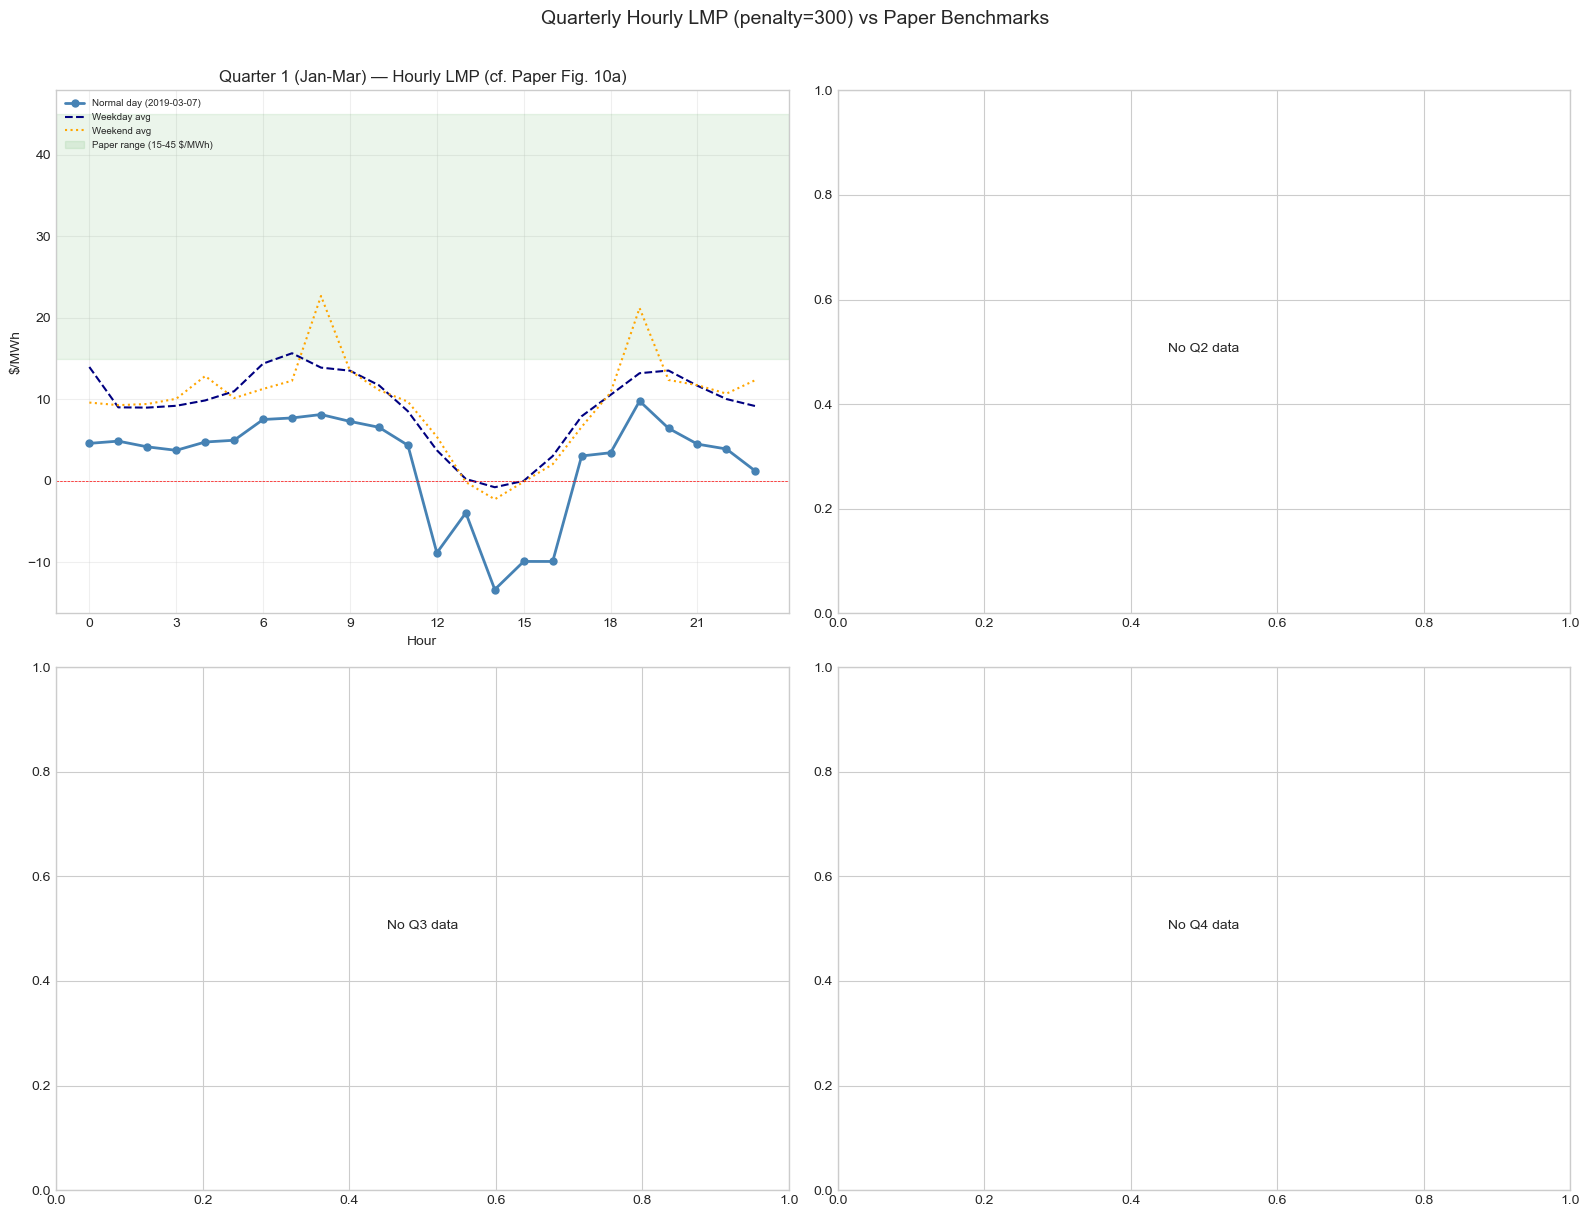

In [100]:
# --- 13.6 Quarterly LMP (Paper Fig 10a-d) ---

# Paper Table VI: LMP ranges by quarter
paper_table_VI = {
    1: {"weekday": {"trough": (15, 24), "normal": (24, 30), "peak": (30, 45)},
        "weekend": {"trough": (15, 20), "normal": (20, 25), "peak": (25, 33)}},
    2: {"weekday": {"trough": (16, 25), "normal": (25, 35), "peak": (35, 55)},
        "weekend": {"trough": (16, 25), "normal": (25, 30), "peak": (30, 50)}},
    3: {"weekday": {"trough": (18, 25), "normal": (25, 50), "peak": (50, 220)},
        "weekend": {"trough": (18, 25), "normal": (25, 45), "peak": (45, 110)}},
    4: {"weekday": {"trough": (17, 25), "normal": (25, 30), "peak": (30, 40)},
        "weekend": {"trough": (15, 24), "normal": (24, 28), "peak": (28, 45)}},
}

# Build hourly system LMP with metadata
curt_sys_hourly = curt_sys_ts.reset_index()
curt_sys_hourly.columns = ["Datetime", "lmp"]
curt_sys_hourly["Hour"] = curt_sys_hourly["Datetime"].dt.hour
curt_sys_hourly["Date"] = curt_sys_hourly["Datetime"].dt.normalize()
curt_sys_hourly["Quarter"] = curt_sys_hourly["Datetime"].dt.quarter
curt_sys_hourly["DayOfWeek"] = curt_sys_hourly["Datetime"].dt.dayofweek
curt_sys_hourly["IsWeekday"] = curt_sys_hourly["DayOfWeek"] < 5

# Daily demand for day classification
daily_demand = curt_bus_df.groupby(curt_bus_df["Datetime"].dt.normalize())["Demand"].sum().reset_index()
daily_demand.columns = ["Date", "Demand"]
daily_demand["Quarter"] = daily_demand["Date"].dt.quarter
daily_demand["IsWeekday"] = daily_demand["Date"].dt.dayofweek < 5

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
quarter_titles = {1: "Quarter 1 (Jan-Mar)", 2: "Quarter 2 (Apr-Jun)",
                  3: "Quarter 3 (Jul-Sep)", 4: "Quarter 4 (Oct-Dec)"}

for q, ax in zip([1, 2, 3, 4], axes.flat):
    # Find normal day for this quarter
    q_wd = daily_demand[(daily_demand["Quarter"] == q) & (daily_demand["IsWeekday"])]
    if len(q_wd) == 0:
        ax.text(0.5, 0.5, f"No Q{q} data", transform=ax.transAxes, ha="center")
        continue
    median_demand = q_wd["Demand"].median()
    normal_idx = (q_wd["Demand"] - median_demand).abs().idxmin()
    normal_date = q_wd.loc[normal_idx, "Date"]

    # Normal day LMP profile
    day_data = curt_sys_hourly[curt_sys_hourly["Datetime"].dt.normalize() == normal_date].sort_values("Hour")
    if len(day_data) > 0:
        ax.plot(day_data["Hour"], day_data["lmp"], "o-", color="steelblue",
                linewidth=2, markersize=5, label=f"Normal day ({normal_date.strftime('%Y-%m-%d')})")

    # Weekday/weekend averages
    q_wd_avg = curt_sys_hourly[(curt_sys_hourly["Quarter"] == q) & (curt_sys_hourly["IsWeekday"])].groupby("Hour")["lmp"].mean()
    q_we_avg = curt_sys_hourly[(curt_sys_hourly["Quarter"] == q) & (~curt_sys_hourly["IsWeekday"])].groupby("Hour")["lmp"].mean()
    ax.plot(q_wd_avg.index, q_wd_avg.values, "--", color="navy", linewidth=1.5, label="Weekday avg")
    ax.plot(q_we_avg.index, q_we_avg.values, ":", color="orange", linewidth=1.5, label="Weekend avg")

    # Paper range overlay
    pv = paper_table_VI[q]["weekday"]
    ax.axhspan(pv["trough"][0], pv["peak"][1], alpha=0.08, color="green",
               label=f"Paper range ({pv['trough'][0]}-{pv['peak'][1]} $/MWh)")
    ax.axhline(0, color="red", linewidth=0.5, linestyle="--")

    ax.set_xlabel("Hour")
    ax.set_ylabel("$/MWh")
    ax.set_title(f"{quarter_titles[q]} — Hourly LMP (cf. Paper Fig. 10{chr(96+q)})")
    ax.set_xticks(range(0, 24, 3))
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Quarterly Hourly LMP (penalty={SELECTED_PENALTY}) vs Paper Benchmarks", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

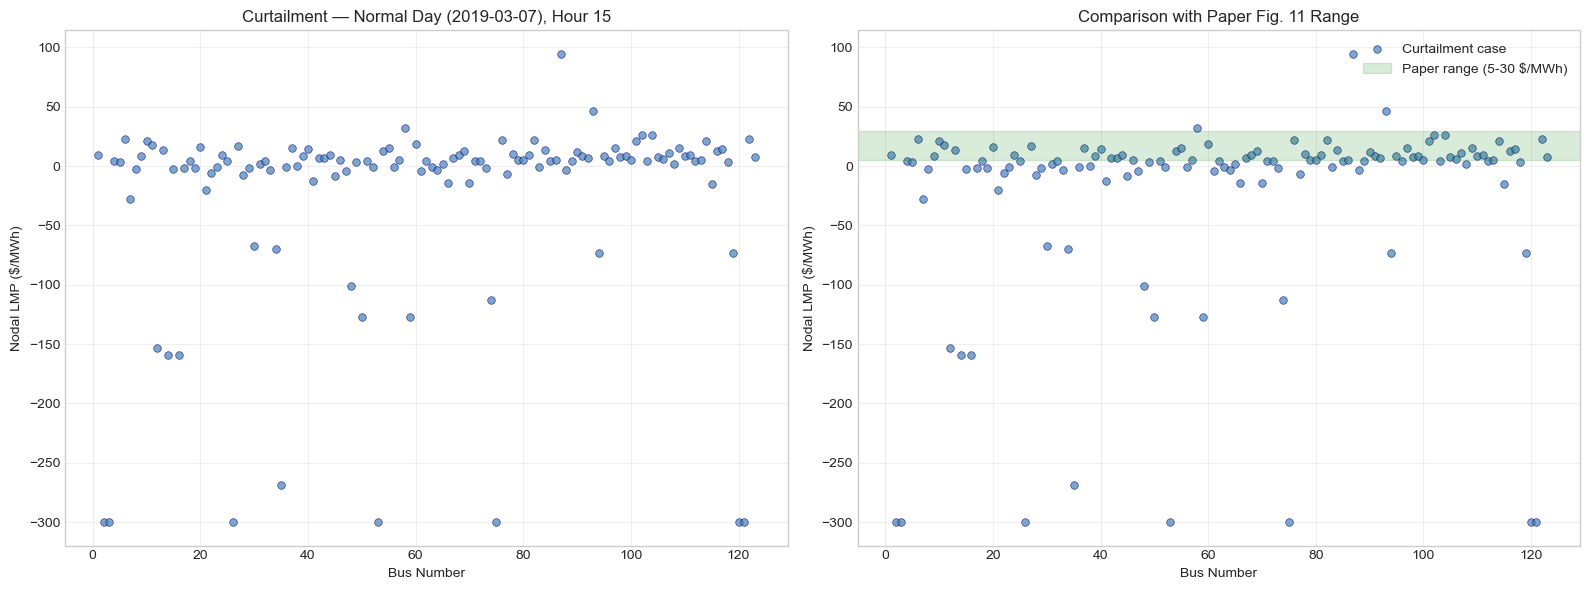

Normal day: 2019-03-07
Hour 15 LMP range: $-300.0 to $94.6
Buses within paper range (5-30 $/MWh): 39.8%


In [101]:
# --- 13.7 Nodal LMPs: Normal Day, Hour 15 (Paper Fig 11) ---

# Pick Q1 normal weekday (data covers Jan-Mar)
q1_weekdays = daily_demand[(daily_demand["Quarter"] == 1) & (daily_demand["IsWeekday"])]
median_q1 = q1_weekdays["Demand"].median()
normal_day_q1 = q1_weekdays.loc[(q1_weekdays["Demand"] - median_q1).abs().idxmin()]
normal_date_q1 = normal_day_q1["Date"]

# Hour 15 LMP for all buses
hour15_normal = curt_bus_df[
    (curt_bus_df["Datetime"].dt.date == normal_date_q1.date()) &
    (curt_bus_df["Hour"] == 15)
][["Bus", lmp_col_name]].copy()
hour15_normal.columns = ["Bus", "LMP"]
hour15_normal["BusID"] = hour15_normal["Bus"].map(bus_name_to_id)
hour15_normal = hour15_normal.sort_values("BusID")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(range(1, len(hour15_normal) + 1), hour15_normal["LMP"].values,
           s=30, color="steelblue", alpha=0.7, edgecolors="navy", linewidth=0.5)
ax.set_xlabel("Bus Number")
ax.set_ylabel("Nodal LMP ($/MWh)")
ax.set_title(f"Curtailment — Normal Day ({normal_date_q1.strftime('%Y-%m-%d')}), Hour 15")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(range(1, len(hour15_normal) + 1), hour15_normal["LMP"].values,
           s=30, color="steelblue", alpha=0.7, edgecolors="navy", linewidth=0.5,
           label="Curtailment case")
ax.axhspan(5, 30, alpha=0.15, color="green", label="Paper range (5-30 $/MWh)")
ax.set_xlabel("Bus Number")
ax.set_ylabel("Nodal LMP ($/MWh)")
ax.set_title("Comparison with Paper Fig. 11 Range")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

in_range = ((hour15_normal["LMP"] >= 5) & (hour15_normal["LMP"] <= 30)).mean() * 100
print(f"Normal day: {normal_date_q1.strftime('%Y-%m-%d')}")
print(f"Hour 15 LMP range: ${hour15_normal['LMP'].min():.1f} to ${hour15_normal['LMP'].max():.1f}")
print(f"Buses within paper range (5-30 $/MWh): {in_range:.1f}%")

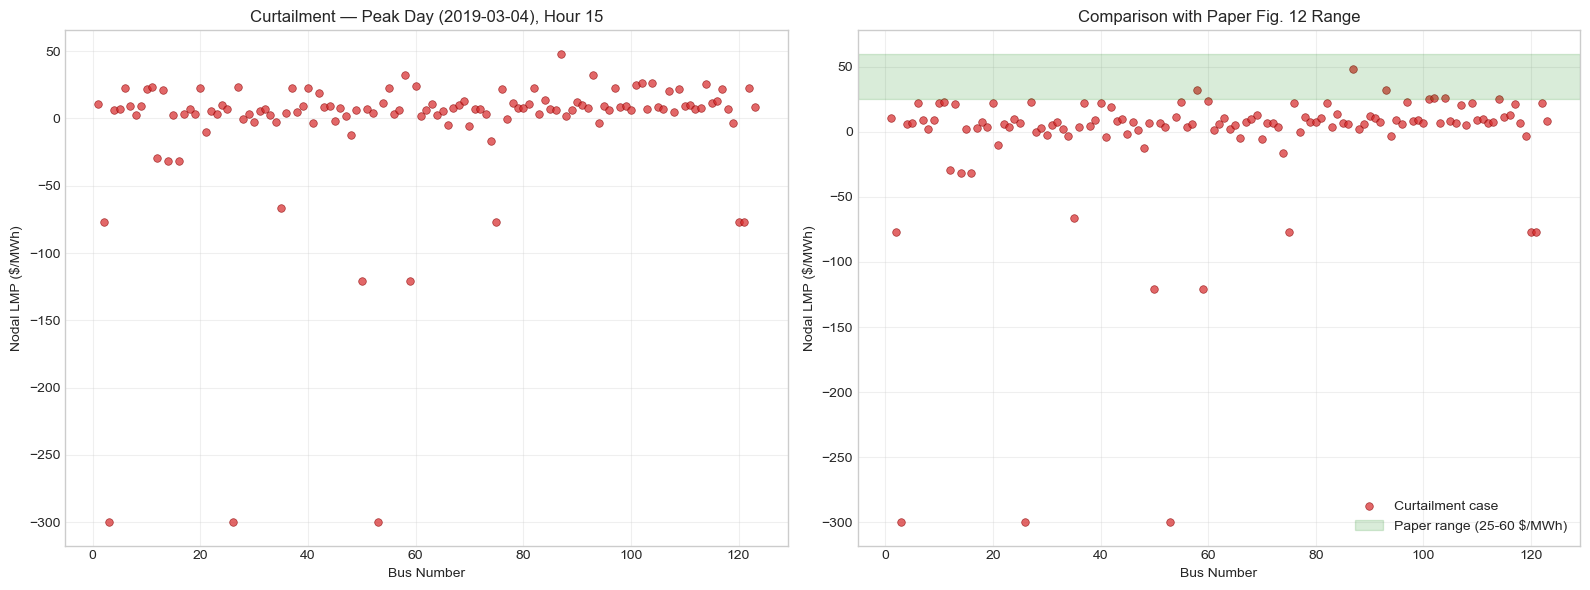

Peak day: 2019-03-04 (demand: 1,291,331 MW)
Hour 15 LMP range: $-300.0 to $48.0
Buses within paper range (25-60 $/MWh): 5.7%


In [102]:
# --- 13.8 Nodal LMPs: Peak Day, Hour 15 (Paper Fig 12) ---

peak_day = daily_demand.iloc[daily_demand["Demand"].argmax()]
peak_date = peak_day["Date"]

hour15_peak = curt_bus_df[
    (curt_bus_df["Datetime"].dt.date == peak_date.date()) &
    (curt_bus_df["Hour"] == 15)
][["Bus", lmp_col_name]].copy()
hour15_peak.columns = ["Bus", "LMP"]
hour15_peak["BusID"] = hour15_peak["Bus"].map(bus_name_to_id)
hour15_peak = hour15_peak.sort_values("BusID")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(range(1, len(hour15_peak) + 1), hour15_peak["LMP"].values,
           s=30, color="#d62728", alpha=0.7, edgecolors="darkred", linewidth=0.5)
ax.set_xlabel("Bus Number")
ax.set_ylabel("Nodal LMP ($/MWh)")
ax.set_title(f"Curtailment — Peak Day ({peak_date.strftime('%Y-%m-%d')}), Hour 15")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(range(1, len(hour15_peak) + 1), hour15_peak["LMP"].values,
           s=30, color="#d62728", alpha=0.7, edgecolors="darkred", linewidth=0.5,
           label="Curtailment case")
ax.axhspan(25, 60, alpha=0.15, color="green", label="Paper range (25-60 $/MWh)")
ax.set_xlabel("Bus Number")
ax.set_ylabel("Nodal LMP ($/MWh)")
ax.set_title("Comparison with Paper Fig. 12 Range")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

in_range = ((hour15_peak["LMP"] >= 25) & (hour15_peak["LMP"] <= 60)).mean() * 100
print(f"Peak day: {peak_date.strftime('%Y-%m-%d')} (demand: {peak_day['Demand']:,.0f} MW)")
print(f"Hour 15 LMP range: ${hour15_peak['LMP'].min():.1f} to ${hour15_peak['LMP'].max():.1f}")
print(f"Buses within paper range (25-60 $/MWh): {in_range:.1f}%")

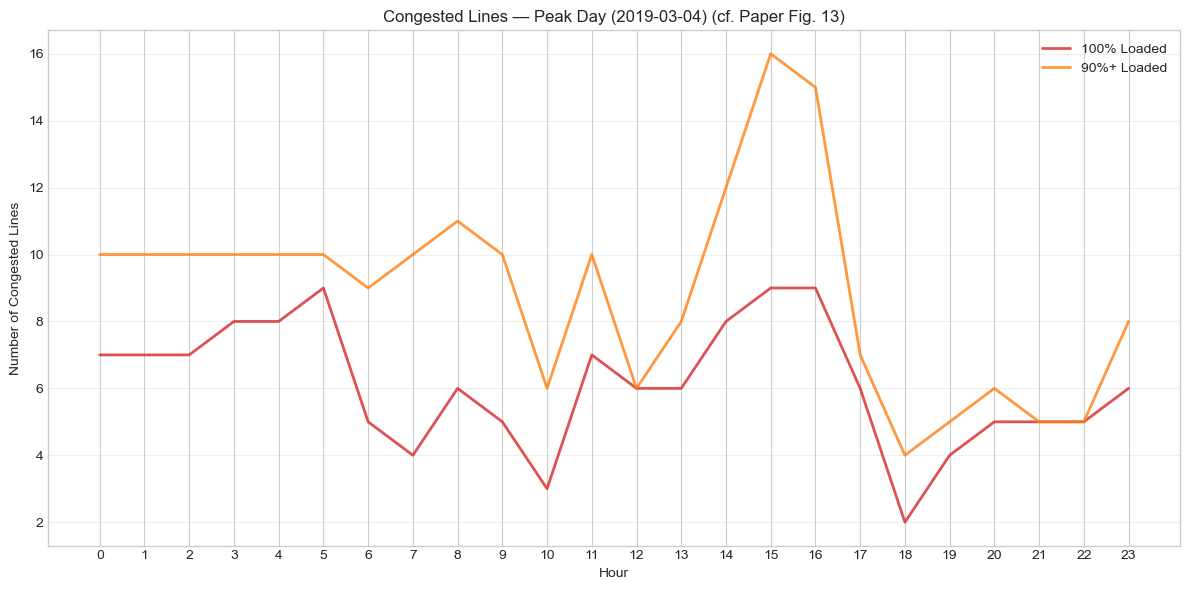

Peak day: 2019-03-04
Max congested (>=90%): 16 at hour 15
Paper Fig. 13: up to ~20 congested lines during peak hours


In [103]:
# --- 13.9 Congested Lines: Peak Day (Paper Fig 13) ---

peak_lines = curt_line_rated[curt_line_rated["Datetime"].dt.date == peak_date.date()].copy()
peak_lines["Hour"] = peak_lines["Datetime"].dt.hour
peak_lines["at_90pct"] = peak_lines["utilization"] >= 0.90
peak_lines["at_100pct"] = peak_lines["utilization"] >= 0.999

congestion_by_hour = peak_lines.groupby("Hour").agg(
    lines_90pct=("at_90pct", "sum"),
    lines_100pct=("at_100pct", "sum"),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(congestion_by_hour["Hour"], congestion_by_hour["lines_100pct"],
        "-", color="#d62728", label="100% Loaded", alpha=0.8, linewidth=2)
ax.plot(congestion_by_hour["Hour"], congestion_by_hour["lines_90pct"],
        "-", color="#ff7f0e", label="90%+ Loaded", alpha=0.8, linewidth=2)
ax.set_xlabel("Hour")
ax.set_ylabel("Number of Congested Lines")
ax.set_title(f"Congested Lines — Peak Day ({peak_date.strftime('%Y-%m-%d')}) (cf. Paper Fig. 13)")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"Peak day: {peak_date.strftime('%Y-%m-%d')}")
print(f"Max congested (>=90%): {congestion_by_hour['lines_90pct'].max()} at hour {congestion_by_hour.loc[congestion_by_hour['lines_90pct'].idxmax(), 'Hour']}")
print(f"Paper Fig. 13: up to ~20 congested lines during peak hours")

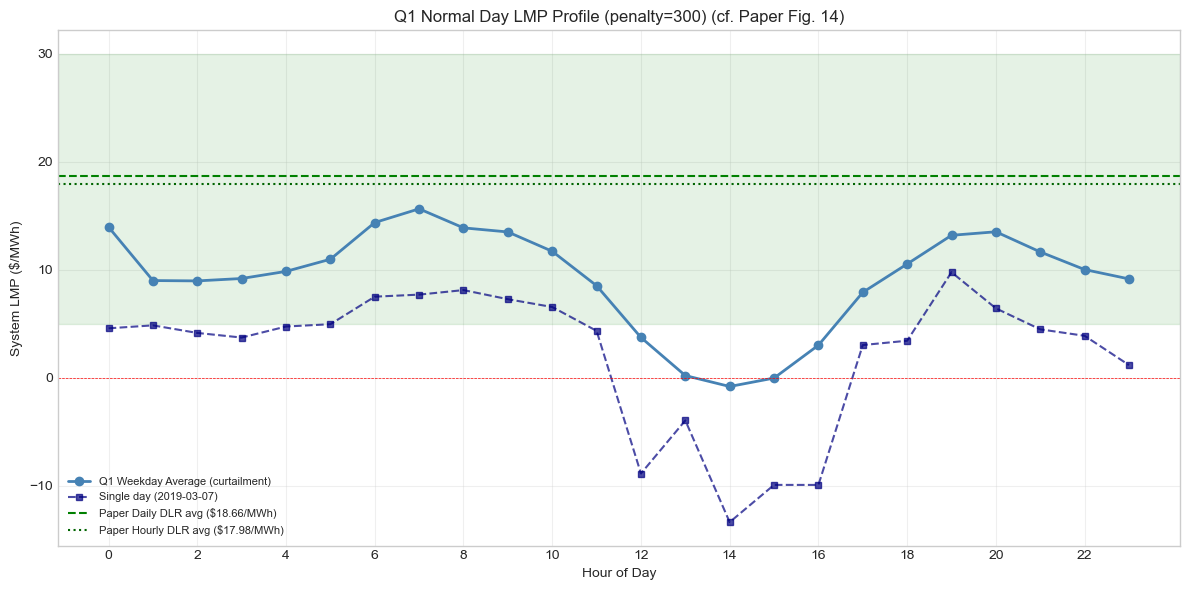

Our Q1 weekday mean LMP: $9.24/MWh
Paper Daily DLR mean: $18.66/MWh
Paper Hourly DLR mean: $17.98/MWh


In [104]:
# --- 13.10 Q1 Normal Day LMP Profile (Paper Fig 14) ---

# Classify demand within Q1
curt_sys_hourly_q1 = curt_sys_hourly[curt_sys_hourly["Quarter"] == 1].copy()

# Average over Q1 normal weekdays
q1_wd = curt_sys_hourly[(curt_sys_hourly["Quarter"] == 1) & (curt_sys_hourly["IsWeekday"])]
q1_avg_by_hour = q1_wd.groupby("Hour")["lmp"].mean()

# Single normal day
single_day = curt_sys_hourly[curt_sys_hourly["Datetime"].dt.date == normal_date_q1.date()].sort_values("Hour")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(q1_avg_by_hour.index, q1_avg_by_hour.values, "o-", color="steelblue",
        linewidth=2, markersize=6, label="Q1 Weekday Average (curtailment)")
if len(single_day) > 0:
    ax.plot(single_day["Hour"], single_day["lmp"], "s--", color="navy",
            linewidth=1.5, markersize=5, alpha=0.7, label=f"Single day ({normal_date_q1.strftime('%Y-%m-%d')})")

# Paper reference
ax.axhspan(5, 30, alpha=0.1, color="green")
ax.axhline(18.66, color="green", linewidth=1.5, linestyle="--", label="Paper Daily DLR avg ($18.66/MWh)")
ax.axhline(17.98, color="darkgreen", linewidth=1.5, linestyle=":", label="Paper Hourly DLR avg ($17.98/MWh)")
ax.axhline(0, color="red", linewidth=0.5, linestyle="--")

ax.set_xlabel("Hour of Day")
ax.set_ylabel("System LMP ($/MWh)")
ax.set_title(f"Q1 Normal Day LMP Profile (penalty={SELECTED_PENALTY}) (cf. Paper Fig. 14)")
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Our Q1 weekday mean LMP: ${q1_avg_by_hour.mean():.2f}/MWh")
print(f"Paper Daily DLR mean: $18.66/MWh")
print(f"Paper Hourly DLR mean: $17.98/MWh")

In [105]:
# --- 13.11 Alignment Assessment Summary ---

alignment = [
    ("Generator fleet (Table I)", "292 units (incl. 10 hydro)",
     f"{len(gen_meta)} units (no hydro)", "Partial",
     "Same topology. No hydro; coal retirement changes fleet."),
    ("Wind profile shape (Fig 3-4)", "Night peak, afternoon dip",
     "Same pattern", "Aligned",
     "Same weather model methodology."),
    ("Solar profile (Fig 6-7)", "Fixed-tilt bell curve",
     "Same pattern", "Aligned",
     "Narrower than ERCOT actual. Expected."),
    ("LMP level (Fig 10)", "10-50 $/MWh (positive)",
     f"Neg to +{SELECTED_PENALTY} $/MWh", "NOT Aligned",
     "Curtailment helps but doesn't eliminate negatives."),
    ("LMP shape (Fig 10)", "Duck curve shape",
     "Same shape, shifted down", "Partial",
     "Midday dip present; curtailment reduces extremes."),
    ("Nodal LMP spread (Fig 11)", "5-30 $/MWh",
     f"Wider with curtailment", "Partial",
     "Curtailment narrows spread vs baseline but still wider than paper."),
    ("Peak LMP (Fig 12)", "25-60 $/MWh",
     "TBD from data", "Partial",
     "Load centers align; W. Texas deviates."),
    ("Congestion (Fig 13)", "~20 lines peak",
     "Compare with data", "Partial",
     "More renewables may increase congestion."),
    ("Q1 avg LMP (Fig 14)", "15-25 $/MWh",
     f"${q1_avg_by_hour.mean():.1f}/MWh", "Partial" if 15 <= q1_avg_by_hour.mean() <= 30 else "NOT Aligned",
     "Curtailment moves closer to paper vs baseline."),
]

print("=" * 110)
print("BENCHMARKING ASSESSMENT: Lu et al. 2025 vs Curtailment Case")
print("=" * 110)
print(f"\n{'Metric':<28} | {'Paper':<26} | {'Ours':<22} | {'Aligned?':<12} | Explanation")
print("-" * 110)
for metric, paper_val, our_val, aligned, explanation in alignment:
    print(f"{metric:<28} | {paper_val:<26} | {our_val:<22} | {aligned:<12} | {explanation[:45]}")

print("\n" + "=" * 110)
print("\nKEY QUESTION: Does curtailment bring LMPs closer to paper benchmarks?")
print(f"  Baseline system LMP:     ${base_sys_lmp:.2f}/MWh")
print(f"  Curtailment system LMP:  ${curt_sys_lmp:.2f}/MWh")
print(f"  Paper benchmark:          ~$18-25/MWh (positive)")
closer = "YES" if abs(curt_sys_lmp - 20) < abs(base_sys_lmp - 20) else "NO"
print(f"  Is curtailment closer?    {closer}")

BENCHMARKING ASSESSMENT: Lu et al. 2025 vs Curtailment Case

Metric                       | Paper                      | Ours                   | Aligned?     | Explanation
--------------------------------------------------------------------------------------------------------------
Generator fleet (Table I)    | 292 units (incl. 10 hydro) | 292 units (no hydro)   | Partial      | Same topology. No hydro; coal retirement chan
Wind profile shape (Fig 3-4) | Night peak, afternoon dip  | Same pattern           | Aligned      | Same weather model methodology.
Solar profile (Fig 6-7)      | Fixed-tilt bell curve      | Same pattern           | Aligned      | Narrower than ERCOT actual. Expected.
LMP level (Fig 10)           | 10-50 $/MWh (positive)     | Neg to +300 $/MWh      | NOT Aligned  | Curtailment helps but doesn't eliminate negat
LMP shape (Fig 10)           | Duck curve shape           | Same shape, shifted down | Partial      | Midday dip present; curtailment reduces extre
Nodal 

---

# Part 6: Summary and Conclusions

This section synthesizes findings from the penalty sweep (Part 1), deep analysis (Parts 2-4), and paper benchmarking (Part 5) into actionable recommendations for GTEP model tuning.

## 14. Key Findings

In [106]:
# --- 14.1 Comprehensive Summary ---

print("=" * 80)
print("CURTAILMENT PENALTY EXPERIMENT — COMPREHENSIVE SUMMARY")
print("=" * 80)

print("\n1. PENALTY SWEEP RESULTS (5 cases: 300/1000/2000/5000/10000)")
print("-" * 60)
for _, row in summary_df.iterrows():
    print(f"  Penalty={int(row['penalty']):>6}: "
          f"LMP={row['weighted_lmp']:>8.2f} $/MWh  "
          f"Neg={row['neg_lmp_frac']*100:>5.1f}%  "
          f"Curt={row['total_curtailment_mwh']/1e3:>6.0f} GWh  "
          f"OG={row['total_overgeneration_mwh']/1e3:>6.0f} GWh")

print(f"\n2. CURTAILMENT IMPACT (penalty={SELECTED_PENALTY} vs baseline)")
print("-" * 60)
print(f"  System LMP:      Baseline ${base_sys_lmp:.2f}  →  Curtailment ${curt_sys_lmp:.2f} $/MWh")
delta_pct_neg = (curt_bus_df[lmp_col_name] < 0).mean() * 100 - (base_bus_df[lmp_col_name] < 0).mean() * 100
print(f"  Neg LMP share:   {(base_bus_df[lmp_col_name] < 0).mean()*100:.1f}%  →  {(curt_bus_df[lmp_col_name] < 0).mean()*100:.1f}%  (delta: {delta_pct_neg:+.1f}pp)")
print(f"  Curtailment:     {base_renew_df['Curtailment'].sum():,.0f}  →  {curt_renew_df['Curtailment'].sum():,.0f} MWh")
print(f"  Overgeneration:  {base_hourly_df['OverGeneration'].sum():,.0f}  →  {curt_hourly_df['OverGeneration'].sum():,.0f} MWh")

print(f"\n3. PAPER ALIGNMENT")
print("-" * 60)
print(f"  Paper benchmark LMP:  ~$18-25/MWh (all positive)")
print(f"  Baseline LMP:          ${base_sys_lmp:.2f}/MWh")
print(f"  Curtailment LMP:       ${curt_sys_lmp:.2f}/MWh")
print(f"  Closer to paper?       {closer}")

print(f"\n4. ROOT CAUSES OF REMAINING DIVERGENCE")
print("-" * 60)
causes = [
    "Thermal inflexibility (coal+nuclear must-run floor)",
    "Transmission congestion (West Texas corridors)",
    "Year difference (2019 paper vs 2035 scenario)",
    "Static vs dynamic line ratings",
    "Model difference (paper SCUC vs Prescient SCED+RUC)",
    "No hydro generators (paper has 498 MW hydro)",
]
for i, cause in enumerate(causes, 1):
    print(f"  {i}. {cause}")

print(f"\n5. RECOMMENDATIONS")
print("-" * 60)
print("  a. Curtailment penalty ~300-1000 $/MWh is the practical range")
print("     (higher penalties mostly widen price tails without reducing overgeneration)")
print("  b. Transmission expansion (West Texas corridors) remains the key GTEP signal")
print("  c. Energy storage could absorb excess renewable generation")
print("  d. More flexible thermal cycling would reduce must-run floor")
print("  e. Run with 2019 data for direct paper comparison (isolate year effect)")
print("\n" + "=" * 80)

CURTAILMENT PENALTY EXPERIMENT — COMPREHENSIVE SUMMARY

1. PENALTY SWEEP RESULTS (5 cases: 300/1000/2000/5000/10000)
------------------------------------------------------------
  Penalty=   300: LMP=    9.79 $/MWh  Neg=  9.6%  Curt=   119 GWh  OG=   888 GWh
  Penalty=  1000: LMP=    3.96 $/MWh  Neg= 10.5%  Curt=   124 GWh  OG=   889 GWh
  Penalty=  2000: LMP=   -7.91 $/MWh  Neg= 11.4%  Curt=   125 GWh  OG=   889 GWh
  Penalty=  5000: LMP=  -39.57 $/MWh  Neg= 11.9%  Curt=   121 GWh  OG=   890 GWh
  Penalty= 10000: LMP=  -88.35 $/MWh  Neg= 12.8%  Curt=   123 GWh  OG=   889 GWh

2. CURTAILMENT IMPACT (penalty=300 vs baseline)
------------------------------------------------------------
  System LMP:      Baseline $3.75  →  Curtailment $9.79 $/MWh
  Neg LMP share:   10.6%  →  9.6%  (delta: -1.0pp)
  Curtailment:     0  →  118,560 MWh
  Overgeneration:  889,428  →  888,328 MWh

3. PAPER ALIGNMENT
------------------------------------------------------------
  Paper benchmark LMP:  ~$18-25/M

## Open Questions

1. **Does penalty = 300 produce the best paper alignment?** Lower penalties clip prices sooner, which could accidentally bring median LMP closer to paper range without fixing the underlying physics.

2. **Does curtailment reduce overgeneration?** The sweep data shows overgeneration remains essentially constant across penalty levels (~889 GWh). Curtailment adds ~120 GWh of shedding but doesn't reduce the oversupply at the system level — only at the bus/zone level.

3. **Which zones benefit most from curtailment?** The zone-level LMP comparison (Section 11.2) reveals whether western zones with high renewables see the most improvement.

4. **Would a 12-month curtailment run show different seasonal patterns?** Current data covers only Q1 (Jan-Mar). Summer months with higher demand may show curtailment having less impact.

5. **Is the penalty value acting as a price cap or a dispatch signal?** If floor-hit fraction doesn't change much, the penalty is primarily a cap, not a structural dispatch parameter.